# Upwelling Indices Comparison

In [2]:
import xarray as xr
import numpy as np
from scipy.ndimage import binary_erosion, binary_dilation
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.projections import PolarAxes
import mpl_toolkits.axisartist.floating_axes as FA
import mpl_toolkits.axisartist.grid_finder as GF

In [3]:
# # mask
# def coastal_band_mask(ds, var='u10', iterations=10):
#     """
#     Create a coastal band mask by dilating the coastline edge.

#     Parameters
#     ----------
#     ds : xr.Dataset
#         Must contain 2D lat/lon coords and the target variable.
#     var : str
#         Variable name used to detect land (NaN) vs ocean.
#     iterations : int
#         Number of dilation steps (~10 km per iteration on a ~10 km grid).

#     Returns
#     -------
#     da_mask : xr.DataArray
#         Boolean mask (True inside the coastal band).
#     """
#     valid2d = np.isfinite(ds[var].mean(dim='time')).values.astype(bool)

#     eroded = binary_erosion(valid2d, structure=np.ones((3, 3)), iterations=1)
#     coast = valid2d & (~eroded)

#     band = binary_dilation(coast, structure=np.ones((3, 3)), iterations=iterations) & valid2d

#     da_mask = xr.DataArray(
#         band,
#         dims=('lat', 'lon'),
#         coords={'lat': ds['lat'], 'lon': ds['lon']},
#     )
#     return da_mask

def coastal_band_mask(ds, var='u10', target_width_km=111):
    """
    Create a coastal band mask with uniform cross-shore width in km.
    """
    da = ds[var]
    if 'time' in da.dims:
        da = da.mean(dim='time')

    valid2d = np.isfinite(da).values.astype(bool)
    lat_vals = ds['lat'].values
    lon_vals = ds['lon'].values
    dlon = np.abs(lon_vals[1] - lon_vals[0])  # grid spacing in degrees

    # Find coastline (easternmost valid cell per row)
    band = np.zeros_like(valid2d, dtype=bool)

    for j in range(valid2d.shape[0]):
        row = valid2d[j, :]
        ocean_cols = np.where(row)[0]
        if len(ocean_cols) == 0:
            continue

        # Coast = easternmost valid cell
        i_coast = ocean_cols[-1]

        # How many cells = target_width_km at this latitude?
        A = 6371.0  # km
        dx_km = A * np.cos(np.deg2rad(lat_vals[j])) * np.deg2rad(dlon)
        n_cells = int(np.round(target_width_km / dx_km))

        # Fill n_cells westward from coast
        i_start = max(i_coast - n_cells, 0)
        band[j, i_start:i_coast + 1] = True

    # Only keep cells that are actually ocean
    band = band & valid2d

    da_mask = xr.DataArray(band, dims=('lat', 'lon'),
                           coords={'lat': ds['lat'], 'lon': ds['lon']})
    return da_mask

In [4]:
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

In [5]:
lat1,lat0 = -16,-5
AV = xr.open_dataset('latitudinal/AV.nc').AV.compute().sel(lat=slice(lat1,lat0))

In [6]:
Ek_t = xr.open_dataset('latitudinal/Winds_components_Lu.nc').etransport.isel(offshore=0)
Ek_t = (Ek_t.swap_dims({'coast_point': 'lat'})
         .drop_vars(['coast_point', 'lon', 'bearing', 'distance', 'f', 'offshore'])
         .rename('Ek_t')).sel(lat=slice(lat1,lat0))
Ek_t

<xarray.DataArray 'Ek_t' (time: 432, lat: 134)> Size: 463kB
[57888 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
Attributes:
    units:      m/s
    long_name:  Ekman transport (normalized by distance)

In [7]:
t_along = xr.open_dataset('Winds_components_Lu.nc').tau_alongshore.mean(
    dim='offshore').swap_dims({'coast_point': 'lat'}).drop_vars(['coast_point', 'bearing'])
t_along

<xarray.DataArray 'tau_alongshore' (time: 432, lat: 134)> Size: 463kB
array([[0.05657707, 0.04826033, 0.05814369, ..., 0.03282552, 0.03398016,
        0.03539143],
       [0.04845767, 0.04312579, 0.05148978, ..., 0.02091777, 0.02155974,
        0.02240733],
       [0.04499081, 0.03963697, 0.04591431, ..., 0.01750821, 0.01762873,
        0.01785168],
       ...,
       [0.08513057, 0.07089712, 0.08593922, ..., 0.06500588, 0.06600709,
        0.06726992],
       [0.0815278 , 0.06884525, 0.08413419, ..., 0.06768828, 0.0691054 ,
        0.07086711],
       [0.07410591, 0.06182153, 0.0748501 , ..., 0.05743211, 0.05820201,
        0.05921074]])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Dimensions without coordinates: lat

In [8]:
CUTI = xr.open_dataset('CUTI_BEUTI_components.nc').CUTI.compute().sel(lat_band=slice(lat0,lat1))
BEUTI = xr.open_dataset('CUTI_BEUTI_components.nc').BEUTI.compute().sel(lat_band=slice(lat0,lat1))
ugeo = xr.open_dataset('CUTI_BEUTI_components.nc').u_geo.compute().sel(lat_band=slice(lat0,lat1))
UGEO = xr.open_dataset('CUTI_BEUTI_components.nc').UGEO.compute().sel(lat_band=slice(lat0,lat1))
CROCO_j = xr.open_dataset('CUTI_BEUTI_components.nc').CROCO_j.compute().sel(lat_band=slice(lat0,lat1))

In [9]:
d = xr.open_dataset('CUTI_BEUTI_components.nc').cross_shore_distance.compute().sel(lat_band=slice(lat0,lat1))
d

<xarray.DataArray 'cross_shore_distance' (lat_band: 11)> Size: 88B
array([110675.6126214 , 110472.92003641, 110237.458738  , 109969.58189847,
       109669.68891651, 109338.22398307, 108959.68046784, 108548.44890858,
       108122.884624  , 107648.20340893, 107142.84303382])
Coordinates:
  * lat_band  (lat_band) float64 88B -5.5 -6.5 -7.5 -8.5 ... -13.5 -14.5 -15.5

In [10]:
CUI = xr.open_dataset('CUI.nc').compute().sel(lat=slice(lat1,lat0))
CUI

<xarray.Dataset> Size: 468kB
Dimensions:  (time: 432, lat: 134)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
Data variables:
    CUI_cc   (time, lat) float64 463kB 2.378 2.615 2.373 ... 1.914 1.983 2.028

In [11]:
u = xr.open_dataset('UV_velocities.nc').compute().transpose('time','lat','lon')
u = u.where(u!=0,np.nan)
mask = coastal_band_mask(u,'u',10).sel(lon=slice(-85,None),lat=slice(lat1,lat0))
u = u.where(mask).u

In [12]:
#Chlorphyll
CHL = xr.open_dataset('../../../NHCS/hincast_1980-2015/Chlorophyll_CROCO.nc').drop_vars('s_rho').compute()
CHL = CHL.where(mask).sel(lon=slice(-85,None),lat=slice(lat1,lat0))
CHL['time'] = CUI.time
CHL

<xarray.Dataset> Size: 90MB
Dimensions:  (time: 432, lat: 134, lon: 194)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
Data variables:
    chla     (time, lat, lon) float64 90MB nan nan nan nan ... nan nan nan nan

In [13]:
## CROCO
wmld = xr.open_dataset('W_mld_Croco.nc').compute()
mask = coastal_band_mask(wmld, 'WMLD', 111)
wmld = wmld.where(mask).sel(lon=slice(-85,None),lat=slice(lat1,lat0))
wmld

<xarray.Dataset> Size: 90MB
Dimensions:  (time: 432, lat: 134, lon: 194)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
Data variables:
    WMLD     (time, lat, lon) float64 90MB nan nan nan nan ... nan nan nan nan

## Latitudinal Structure

## Seasonality

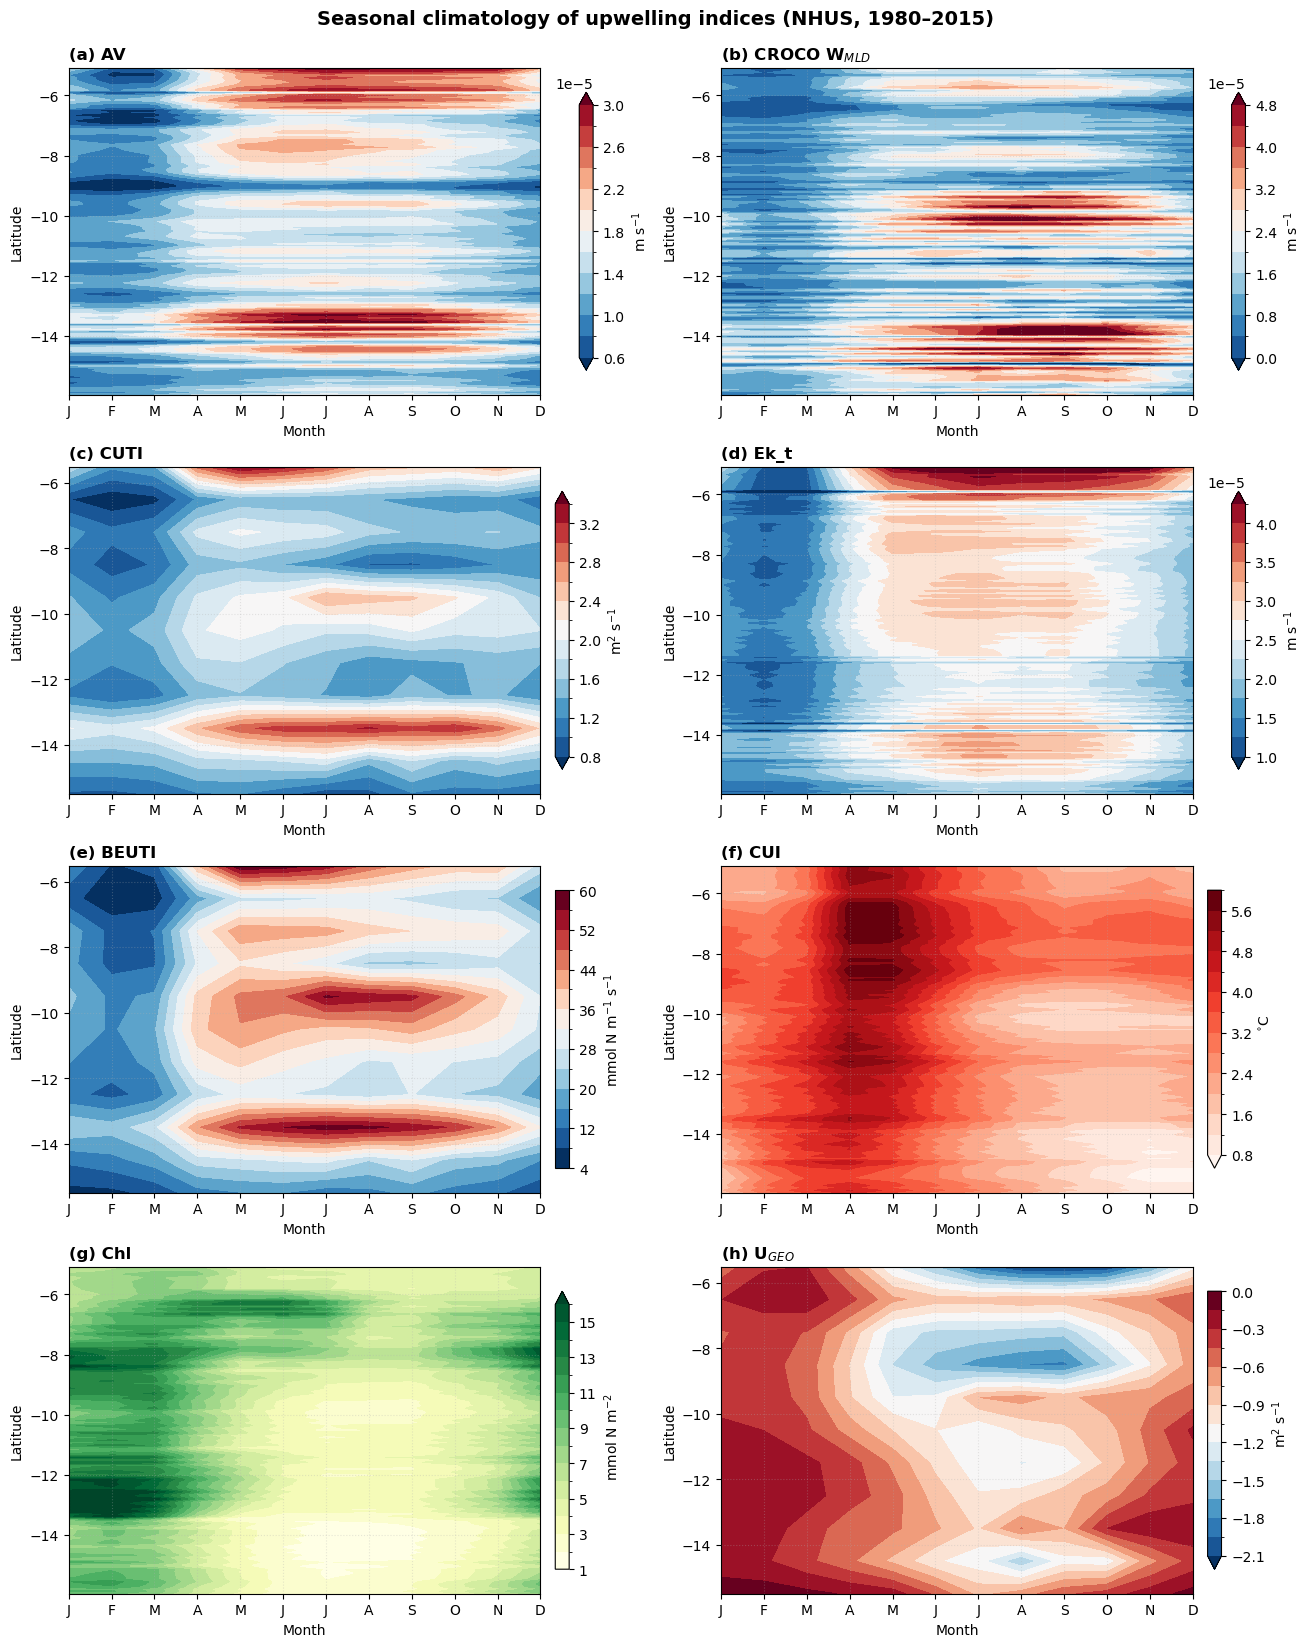

In [14]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

fig, ax = plt.subplots(4, 2, figsize=(13, 16), constrained_layout=True)

panels = [
    (ax[0,0], seasonality(AV).mean('lon'),                'AV',    'm s$^{-1}$',                          'RdBu_r', None),
    (ax[0,1], seasonality(wmld).WMLD.mean('lon'),         'CROCO W$_{MLD}$', 'm s$^{-1}$',                 'RdBu_r', None),
    (ax[1,0], seasonality(CUTI).mean('lon'),              'CUTI',  'm$^{2}$ s$^{-1}$',                    'RdBu_r', None),
    (ax[1,1], seasonality(Ek_t),                            'Ek_t',   'm s$^{-1}$',                          'RdBu_r', None),
    (ax[2,0], seasonality(BEUTI).mean('lon'),             'BEUTI', 'mmol N m$^{-1}$ s$^{-1}$',            'RdBu_r', None),
    (ax[2,1], seasonality(CUI.CUI_cc),                     'CUI',   '$^{\circ}$C',                         'Reds',   None),
    (ax[3,0], seasonality(CHL.chla).mean('lon'),          'Chl',   'mmol N m$^{-2}$',                     'YlGn',   None),
    (ax[3,1], seasonality(UGEO).mean('lon'),              'U$_{GEO}$', 'm$^{2}$ s$^{-1}$',                'RdBu_r', None),
]

panel_labels = list('abcdefgh')

for (a, da, title, units, cmap, _), label in zip(panels, panel_labels):
    p = da.plot.contourf(
        x='month',
        ax=a,
        robust=True,
        cmap=cmap,
        levels=15,
        add_colorbar=True,
        cbar_kwargs={'label': units, 'shrink': 0.85, 'pad': 0.02},
    )
    a.set_title(f'({label}) {title}', loc='left', fontsize=12, fontweight='bold')
    a.set_xlabel('Month')
    a.set_ylabel('Latitude')
    a.set_xticks(range(1, 13))
    a.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
    a.grid(alpha=0.3, linestyle=':')

fig.suptitle('Seasonal climatology of upwelling indices (NHUS, 1980–2015)',
             fontsize=14, fontweight='bold', y=1.02)

# --- Save to PDF ---
# with PdfPages('upwelling_indices_seasonality_3.pdf') as pdf:
#     pdf.savefig(fig, bbox_inches='tight')

plt.show()

### Seasonality paper plot

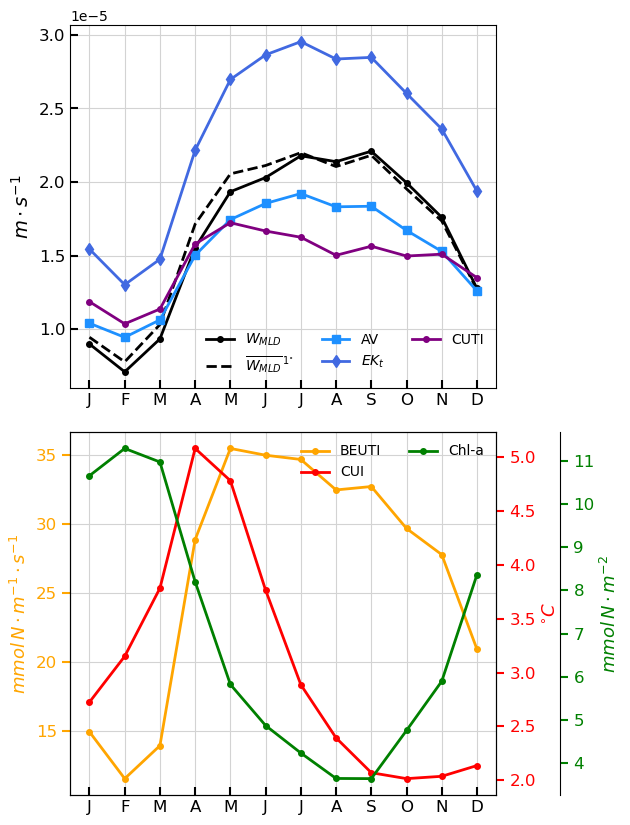

In [15]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MultipleLocator


def make_patch_spines_invisible(ax):
    ax.set_frame_on(True)
    ax.patch.set_visible(False)
    for sp in ax.spines.values():
        sp.set_visible(False)


# d = (1/12) * 10 * 111 * 1000

# ============================================================
# Seasonal cycles
# ============================================================
wmlds   = seasonality(wmld.WMLD).mean(dim=('lat', 'lon'))
Croco_j = seasonality(CROCO_j).mean(dim=('lon', 'lat_band'))
AVs     = seasonality(AV).mean(dim=('lat', 'lon'))
Ek_ts   = seasonality(Ek_t).mean(dim='lat')
CUTIs   = seasonality(CUTI/d).mean(dim=('lat_band', 'lon')) 
UGEOs   = seasonality(UGEO/d).mean(dim=('lat_band', 'lon'))

BEUTIs  = seasonality(BEUTI).mean(dim=('lat_band', 'lon'))
CUIs    = seasonality(CUI.CUI_cc).mean(dim='lat')
CHLs    = seasonality(CHL.chla).mean(dim=('lat', 'lon'))

months = ['J','F','M','A','M','J','J','A','S','O','N','D']


def make_patch_spines_invisible(ax):
    ax.set_frame_on(True)
    ax.patch.set_visible(False)
    for sp in ax.spines.values():
        sp.set_visible(False)


# ============================================================
# Figure with two panels
# ============================================================
fig, (axL, axR_host) = plt.subplots(2, 1, figsize=(5.5, 10))

# ------------------------------------------------------------
# Upper PANEL — wind-based indices (all share m/s)
# ------------------------------------------------------------
axL.plot(wmlds.month,   wmlds,   color='black',      lw=2, marker='o', ms=4, label='$W_{MLD}$')
axL.plot(Croco_j.month, Croco_j, color='black',       lw=2, linestyle='--', ms=4, label=r'$\overline{W_{MLD}}^{\,1^{\circ}}$')
axL.plot(AVs.month,     AVs,     color='dodgerblue', lw=2, marker='s', ms=6, label='AV')
axL.plot(Ek_ts.month,   Ek_ts,   color='royalblue',  lw=2, marker='d', ms=6, label='$EK_t$')
axL.plot(CUTIs.month,   CUTIs,   color='purple',     lw=2, marker='o', ms=4, label='CUTI')
# axL.plot(UGEOs.month,   UGEOs,   color='teal',       lw=2, marker='^', ms=5, label='$U_{GEO}$')

axL.set_ylabel('$m \\cdot s^{-1}$', fontsize=14)
axL.set_xticks(range(1, 13))
axL.set_xticklabels(months, fontsize=12)
axL.tick_params(axis='both', labelsize=12, direction='in', size=6, width=1.5)
axL.grid(True, color='lightgrey')
axL.set_axisbelow(True)
# axL.set_title('(a) Wind-based indices', fontsize=13, loc='left', fontweight='bold')
axL.legend(fontsize=10, ncol=3, frameon=False, loc='lower right')

# ------------------------------------------------------------
# Bottom PANEL — BEUTI, CUI, Chl (different units → twin axes)
# ------------------------------------------------------------
par1 = axR_host.twinx()          # CUI (°C)
par2 = axR_host.twinx()          # Chl (mmol N m⁻²)

par2.spines["right"].set_position(("axes", 1.15))
make_patch_spines_invisible(par2)
par2.spines["right"].set_visible(True)

# --- BEUTI on host ---
BEUTi, = axR_host.plot(BEUTIs.month, BEUTIs,
                       color='orange', lw=2, marker='o', ms=4, label='BEUTI')

# --- CUI on par1 ---
CUi,   = par1.plot(CUIs.month,   CUIs,
                   color='red',    lw=2, marker='o', ms=4, label='CUI')

# --- Chl on par2 ---
Chli,  = par2.plot(CHLs.month,   CHLs,
                   color='green',  lw=2, marker='o', ms=4, label='Chl-a')

# Labels and colors
axR_host.set_ylabel('$mmol\\,N \\cdot m^{-1} \\cdot s^{-1}$', fontsize=13)
par1.set_ylabel('$^{\\circ}C$', fontsize=13)
par2.set_ylabel('$mmol\\,N \\cdot m^{-2}$', fontsize=13)

axR_host.yaxis.label.set_color('orange')
par1.yaxis.label.set_color('red')
par2.yaxis.label.set_color('green')

tkw = dict(size=6, width=1.5)
axR_host.tick_params(axis='y', colors='orange', labelsize=12, **tkw)
par1.tick_params(axis='y',     colors='red',    labelsize=12, **tkw)
par2.tick_params(axis='y',     colors='green',  labelsize=12, **tkw)
axR_host.tick_params(axis='x', labelsize=12, direction='in', **tkw)

axR_host.set_xticks(range(1, 13))
axR_host.set_xticklabels(months, fontsize=12)
axR_host.grid(True, color='lightgrey')
axR_host.set_axisbelow(True)
# axR_host.set_title('(b) SST, Chl and nutrient indices', fontsize=13, loc='left', fontweight='bold')

# Combined legend for right panel
handles, labels = [], []
for a_ in (axR_host, par1, par2):
    h, l = a_.get_legend_handles_labels()
    handles += h
    labels  += l
axR_host.legend(handles, labels, fontsize=10, ncol=2,frameon=False, loc='upper right')
# axL.legend(fontsize=10, ncol=3, frameon=False, loc='lower right')

# fig.suptitle('Seasonal cycle of upwelling indices', fontsize=16, y=1.02)
fig.subplots_adjust(top=0.88, hspace=0.12)

# --- Save ---
# with PdfPages('figures/Seasonal_cycle_split_2.pdf') as pdf:
#     pdf.savefig(fig, bbox_inches='tight')

plt.show()

(-1e-05, 1e-05)

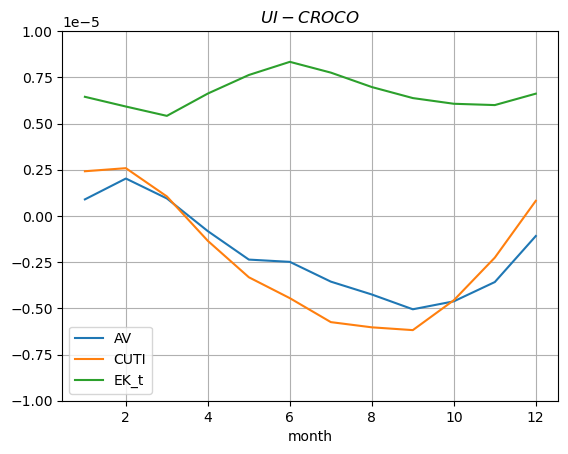

In [16]:
seasonality(AV-wmld.WMLD).mean(dim=('lon','lat')).plot(label='AV')
seasonality((CUTI/d)-CROCO_j).mean(dim=('lon','lat_band')).plot(label='CUTI')
seasonality(Ek_t-wmld.WMLD.mean('lon')).mean('lat').plot(label='EK_t')
plt.legend()
plt.grid(True)
plt.title('$UI - CROCO$')
plt.ylim(-10e-6,10e-6)

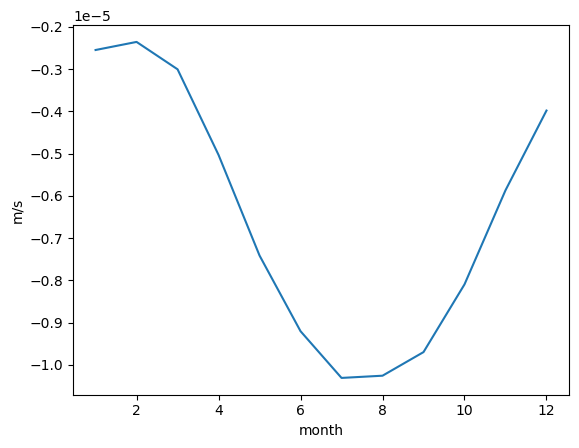

In [17]:
# seasonality(u).mean(dim=('lon','lat')).rename('m/s').plot(label='u')
seasonality(UGEO/d).mean(dim=('lon','lat_band')).rename('m/s').plot(label='ugeo')

### Taylor Plot

In [18]:
# ============================================================
# 1. Scoring function
# ============================================================
def taylor_stats(test, reference):
    """Return (std_test, std_ref, correlation, centered RMSE)."""
    test = np.asarray(test).ravel()
    reference = np.asarray(reference).ravel()

    # drop NaNs pairwise
    mask = np.isfinite(test) & np.isfinite(reference)
    test, reference = test[mask], reference[mask]

    std_test = np.std(test, ddof=1)
    std_ref  = np.std(reference, ddof=1)
    corr     = np.corrcoef(test, reference)[0, 1]
    rmse     = np.sqrt(std_test**2 + std_ref**2 - 2*std_test*std_ref*corr)
    return std_test, std_ref, corr, rmse

In [19]:
# ============================================================
# 2. Build each (index, reference) pair and score
# ============================================================
#pre-processing

# Full W_mld (3D field) for AV and Ek_t
wmld_full = seasonality(wmld.WMLD).mean(dim=('lon','lat'))

# AV vs W_mld — both have (time, lat, lon)
av_pair   = (seasonality(AV).mean(dim=('lon','lat')),  wmld_full)

# Ek_t vs W_mld averaged over lon (Ek_t only has time, lat)
bui_pair  = (seasonality(Ek_t).mean('lat'), wmld_full)

# CUTI vs CROCO_j (both on lat_band)
cuti_pair = (seasonality(CUTI / d).mean(dim=('lon','lat_band')), seasonality(CROCO_j).mean(dim=('lon','lat_band')))

pairs = {
    'AV':    av_pair,
    'EK_t':   bui_pair,
    'CUTI': cuti_pair,
}

# Compute stats for each pair
rows = []
for name, (test, ref) in pairs.items():
    std_t, std_r, corr, rmse = taylor_stats(test.values, ref.values)
    rows.append({
        'name':     name,
        'std_test': std_t,
        'std_ref':  std_r,
        'corr':     corr,
        'rmse':     rmse,
        'std_norm': std_t / std_r,   # normalized std (test / reference)
    })

stats_df = pd.DataFrame(rows).set_index('name')
print(stats_df.round(8))

      std_test   std_ref      corr          rmse  std_norm
name                                                      
AV    0.000004  0.000005  0.990078  2.020000e-06  0.647598
EK_t  0.000006  0.000005  0.993225  8.600000e-07  1.098008
CUTI  0.000002  0.000005  0.933862  3.300000e-06  0.420137


In [20]:
print(stats_df.to_string(float_format='{:.3e}'.format))

      std_test   std_ref      corr      rmse  std_norm
name                                                  
AV   3.542e-06 5.470e-06 9.901e-01 2.025e-06 6.476e-01
EK_t 6.006e-06 5.470e-06 9.932e-01 8.559e-07 1.098e+00
CUTI 2.213e-06 5.267e-06 9.339e-01 3.297e-06 4.201e-01


In [21]:
# ============================================================
# 3. Taylor diagram plotting function (uses normalized stats)
# ============================================================
def plot_taylor(stats_df, title='Taylor diagram', savepath=None):
    """
    stats_df must have columns: std_norm, corr
    Each row becomes a point. Reference is always at (corr=1, std=1).
    """
    fig = plt.figure(figsize=(8-2, 7-2))

    # Correlation ticks
    corr_ticks  = np.array([0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1.0])
    theta_ticks = np.arccos(corr_ticks)
    gl_theta = GF.FixedLocator(theta_ticks)
    tf_theta = GF.DictFormatter(dict(zip(theta_ticks, map(str, corr_ticks))))

    # Radial range (normalized std)
    smax = max(1.6, 1.2 * stats_df['std_norm'].max())

    tr = PolarAxes.PolarTransform()
    ghelper = FA.GridHelperCurveLinear(
        tr,
        extremes=(0, np.pi/2, 0, smax),
        grid_locator1=gl_theta,
        tick_formatter1=tf_theta,
    )

    ax = FA.FloatingSubplot(fig, 111, grid_helper=ghelper)
    fig.add_subplot(ax)

    ax.axis["top"].set_axis_direction("bottom")
    ax.axis["top"].toggle(ticklabels=True, label=True)
    ax.axis["top"].major_ticklabels.set_axis_direction("top")
    ax.axis["top"].label.set_axis_direction("top")
    ax.axis["top"].label.set_text("Correlation")

    ax.axis["left"].set_axis_direction("bottom")
    ax.axis["left"].label.set_text("Normalized standard deviation")

    ax.axis["right"].set_axis_direction("top")
    ax.axis["right"].toggle(ticklabels=True)
    ax.axis["right"].major_ticklabels.set_axis_direction("left")

    ax.axis["bottom"].set_visible(False)
    ax.grid(True)

    pax = ax.get_aux_axes(tr)

    # Reference point and unit-std circle
    pax.plot(0, 1.0, 'k*', markersize=14, label='Reference')
    t = np.linspace(0, np.pi/2, 100)
    pax.plot(t, np.ones_like(t), 'k--', alpha=0.5, lw=1)

    # RMSE contours (centered on reference at std=1)
    rs, ts = np.meshgrid(np.linspace(0, smax, 100), np.linspace(0, np.pi/2, 100))
    rms = np.sqrt(1.0 + rs**2 - 2*rs*np.cos(ts))
    cs = pax.contour(ts, rs, rms, levels=5, colors='gray', linestyles=':', alpha=0.6)
    pax.clabel(cs, inline=True, fontsize=8, fmt='%.2f')

    # Plot each model
    palette = {
        'AV':    ('dodgerblue', 's'),
        'EK_t':   ('royalblue',  'd'),
        'CUTI*': ('purple',     'o'),
    }

    for name, row in stats_df.iterrows():
        color, marker = palette.get(name, ('gray', 'x'))
        theta = np.arccos(row['corr'])
        pax.plot(theta, row['std_norm'],
                 marker=marker, color=color,
                 markersize=12, linestyle='',
                 label=f"{name} (r={row['corr']:.2f})")

    pax.legend(loc='upper right', fontsize=10, numpoints=1, frameon=True)
    ax.set_title(title, fontsize=13, pad=20)

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, bbox_inches='tight')
    plt.show()

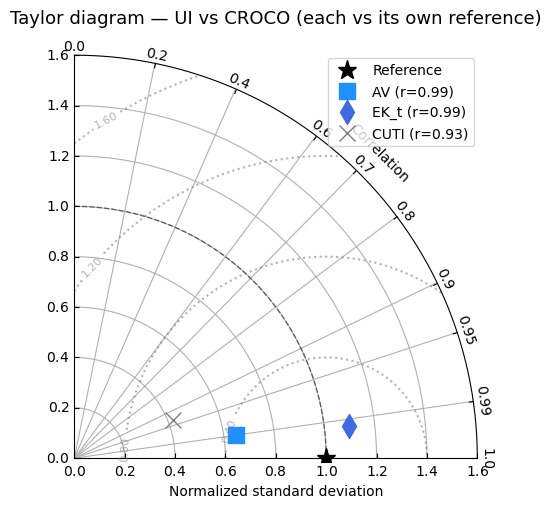

In [22]:
# ============================================================
# 4. Call it
# ============================================================
plot_taylor(
    stats_df,
    title='Taylor diagram — UI vs CROCO (each vs its own reference)',
    # savepath='figures/taylor_diagram_winds.pdf',
)

#### All UIs

In [23]:
# ============================================================
# 3. Taylor diagram plotting function (uses normalized stats)
# ============================================================
def plot_taylor_all(stats_df, title='Taylor diagram', savepath=None):
    """
    stats_df must have columns: std_norm, corr
    Each row becomes a point. Reference is always at (corr=1, std=1).
    """
    fig = plt.figure(figsize=(8-2, 7-2))

    # Correlation ticks
    corr_ticks  = np.array([0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1.0])
    theta_ticks = np.arccos(corr_ticks)
    gl_theta = GF.FixedLocator(theta_ticks)
    tf_theta = GF.DictFormatter(dict(zip(theta_ticks, map(str, corr_ticks))))

    # Radial range (normalized std)
    smax = max(1.6, 1.2 * stats_df['std_norm'].max())

    tr = PolarAxes.PolarTransform()
    ghelper = FA.GridHelperCurveLinear(
        tr,
        extremes=(0, np.pi/2, 0, smax),
        grid_locator1=gl_theta,
        tick_formatter1=tf_theta,
    )

    ax = FA.FloatingSubplot(fig, 111, grid_helper=ghelper)
    fig.add_subplot(ax)

    ax.axis["top"].set_axis_direction("bottom")
    ax.axis["top"].toggle(ticklabels=True, label=True)
    ax.axis["top"].major_ticklabels.set_axis_direction("top")
    ax.axis["top"].label.set_axis_direction("top")
    ax.axis["top"].label.set_text("Correlation")

    ax.axis["left"].set_axis_direction("bottom")
    ax.axis["left"].label.set_text("Normalized standard deviation")

    ax.axis["right"].set_axis_direction("top")
    ax.axis["right"].toggle(ticklabels=True)
    ax.axis["right"].major_ticklabels.set_axis_direction("left")

    ax.axis["bottom"].set_visible(False)
    ax.grid(True)

    pax = ax.get_aux_axes(tr)

    # Reference point and unit-std circle
    pax.plot(0, 1.0, 'k*', markersize=14, label='Reference')
    t = np.linspace(0, np.pi/2, 100)
    pax.plot(t, np.ones_like(t), 'k--', alpha=0.5, lw=1)

    # RMSE contours (centered on reference at std=1)
    rs, ts = np.meshgrid(np.linspace(0, smax, 100), np.linspace(0, np.pi/2, 100))
    rms = np.sqrt(1.0 + rs**2 - 2*rs*np.cos(ts))
    cs = pax.contour(ts, rs, rms, levels=5, colors='gray', linestyles=':', alpha=0.6)
    pax.clabel(cs, inline=True, fontsize=8, fmt='%.2f')

    # Plot each model
    palette = {
        'AV':     ('dodgerblue', 's'),
        'EK_t':   ('royalblue',  'd'),
        'CUTI*':  ('purple',     'o'),
        'BEUTI*': ('orange',     '^'),
        'CUI':    ('red',        'v'),
        'CHLs':   ('green',      'P'),
    }
    for name, row in stats_df.iterrows():
        color, marker = palette.get(name, ('gray', 'x'))
        theta = np.arccos(row['corr'])
        pax.plot(theta, row['std_norm'],
                 marker=marker, color=color,
                 markersize=12, linestyle='',
                 label=f"{name} (r={row['corr']:.2f})")

    pax.legend(loc='upper right', fontsize=10, numpoints=1, frameon=True)
    ax.set_title(title, fontsize=13, pad=20)

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, bbox_inches='tight')
    plt.show()

In [24]:
def zscore(x, dim='time'):
    return (x - x.mean(dim=dim)) / x.std(dim=dim)

### Taylor skill table

In [25]:
import datetime

NINO = [
    (datetime.datetime(1982, 8, 1), datetime.datetime(1983, 12, 31)),
    (datetime.datetime(1997, 4, 1), datetime.datetime(1998, 8, 30)),
]

def drop_en_events(da, en_windows=NINO, dim='time'):
    """Mask out El Niño periods from a time series."""
    mask = np.ones(da.sizes[dim], dtype=bool)
    time = da[dim].values
    for start, end in en_windows:
        start64 = np.datetime64(start)
        end64   = np.datetime64(end)
        mask &= ~((time >= start64) & (time <= end64))
    return da.isel({dim: mask})

In [26]:
def taylor_skill(std_norm, corr):
    return (4 * (1 + corr)**4) / ((std_norm + 1/std_norm)**2 * (1 + 1)**4)

def lagged_correlation(test, ref, max_lag=6):
    """
    Find the lag (in months) that maximizes |Pearson correlation|.
    Positive lag: test lags reference (test responds after ref).
    Negative lag: test leads reference.
    """
    t = np.asarray(test).ravel()
    r = np.asarray(ref).ravel()
    mask = np.isfinite(t) & np.isfinite(r)
    t, r = t[mask], r[mask]

    lags = np.arange(-max_lag, max_lag + 1)
    corrs = []
    for lag in lags:
        if lag < 0:
            # test leads: shift test forward
            tt, rr = t[:lag], r[-lag:]
        elif lag > 0:
            # test lags: shift test backward
            tt, rr = t[lag:], r[:-lag]
        else:
            tt, rr = t, r
        corrs.append(np.corrcoef(tt, rr)[0, 1])

    corrs = np.array(corrs)
    # Pick the lag with maximum absolute correlation (handles anti-correlation)
    best_idx = np.argmax(np.abs(corrs))
    return lags[best_idx], corrs[best_idx]

In [27]:
wmlds  = seasonality(drop_en_events(wmld.WMLD)).mean(dim=('lat', 'lon'))
Croco_j = seasonality(drop_en_events(CROCO_j)).mean(dim=('lon','lat_band'))
AVs    = seasonality(drop_en_events(AV)).mean(dim=('lat', 'lon'))
EKts   = seasonality(drop_en_events(Ek_t)).mean(dim='lat')
CUTIs  = seasonality(drop_en_events(CUTI/d)).mean(dim=('lat_band', 'lon'))
BEUTIs = seasonality(drop_en_events(BEUTI)).mean(dim=('lat_band', 'lon'))
CUIs   = seasonality(drop_en_events(CUI.CUI_cc)).mean(dim='lat')
CHLs   = seasonality(drop_en_events(CHL.chla)).mean(dim=('lat', 'lon'))

In [28]:
# Group 1: Dynamical indices (same units as W_mld)
dynamical_pairs = {
    'AV':    (AVs,    wmlds),
    'EK_t':  (EKts,   wmlds),
    'CUTI*': (CUTIs,  Croco_j),
}

# Group 2: Proxy indices (correlation only)
proxy_pairs = {
    'BEUTI*': (BEUTIs, Croco_j),
    'CUI':   (CUIs,   wmlds),
    'Chl':   (CHLs,   wmlds),
}

In [29]:
## for Winds
from scipy.stats import pearsonr, spearmanr

dyn_rows = []
for name, (test, ref) in dynamical_pairs.items():
    std_t, std_r, corr, rmse = taylor_stats(test.values, ref.values)
    std_norm = std_t / std_r
    dyn_rows.append({
        'name': name,
        'corr': corr,
        'std_norm': std_norm,
        'rmse_norm': rmse / std_r,
        'taylor_skill': taylor_skill(std_norm, corr),
    })

dyn_df = pd.DataFrame(dyn_rows).set_index('name').sort_values('taylor_skill', ascending=False)
print("=== Dynamical indices ===")
print(dyn_df.round(3))


# --- Proxy indices with lag ---
proxy_rows = []
for name, (test, ref) in proxy_pairs.items():
    t = test.values.ravel()
    r = ref.values.ravel()
    mask = np.isfinite(t) & np.isfinite(r)
    t, r = t[mask], r[mask]

    pearson_0  = pearsonr(t, r)[0]
    spearman_0 = spearmanr(t, r)[0]
    best_lag, best_corr = lagged_correlation(t, r, max_lag=5)

    proxy_rows.append({
        'name':         name,
        'pearson':      pearson_0,
        'spearman':     spearman_0,
        'best_lag_mo':  best_lag,
        'corr_at_lag':  best_corr,
    })

proxy_df = pd.DataFrame(proxy_rows).set_index('name')
print("\n=== Proxy indices ===")
print(proxy_df.round(3))

=== Dynamical indices ===
        corr  std_norm  rmse_norm  taylor_skill
name                                           
EK_t   0.993     1.075      0.142         0.981
AV     0.989     0.633      0.385         0.800
CUTI*  0.904     0.424      0.643         0.425

=== Proxy indices ===
        pearson  spearman  best_lag_mo  corr_at_lag
name                                               
BEUTI*    0.978     0.853            0        0.978
CUI      -0.173    -0.385            2       -0.955
Chl      -0.987    -0.979            0       -0.987


In [30]:
# Compute stats for each pair
rows = []
for name, (test, ref) in dynamical_pairs.items():
    std_t, std_r, corr, rmse = taylor_stats(test.values, ref.values)
    rows.append({
        'name':     name,
        'std_test': std_t,
        'std_ref':  std_r,
        'corr':     corr,
        'rmse':     rmse,
        'std_norm': std_t / std_r,   # normalized std (test / reference)
    })

stats_df = pd.DataFrame(rows).set_index('name')
print(stats_df.to_string(float_format='{:.3e}'.format))

       std_test   std_ref      corr      rmse  std_norm
name                                                   
AV    3.506e-06 5.537e-06 9.892e-01 2.132e-06 6.331e-01
EK_t  5.951e-06 5.537e-06 9.932e-01 7.873e-07 1.075e+00
CUTI* 2.261e-06 5.329e-06 9.039e-01 3.425e-06 4.243e-01


* Case A (EK_t)
Same waveform, just stretched vertically
→ high correlation, moderate RMSE

* Case B (CUTI*)
Wrong waveform shape / shifted peaks
→ low correlation, large RMSE

* amplitude is not RMSE
* RMSE “sees” alignment first, how well fitted it is to the reference Wj

### Now we exclude EN

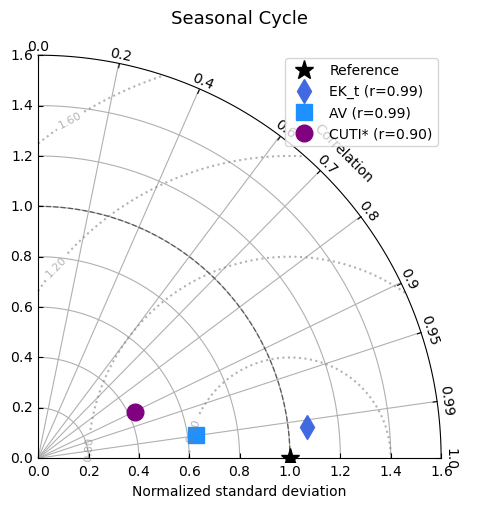

In [30]:
plot_taylor(
    dyn_df,
    title='Seasonal Cycle',
    # savepath='figures/taylor_diagram_winds.pdf',
)

* Although Ek_t and AV achieve nearly identical correlations with the seasonal cycle of W_mld (r = 0.99), the Taylor diagram (Figure X) shows that AV is closest to the reference, with a normalized standard deviation of 0.67 compared to Ek_t's 1.45. Ek_t substantially overestimates the amplitude of the seasonal cycle, while AV provides a more conservative and physically realistic estimate

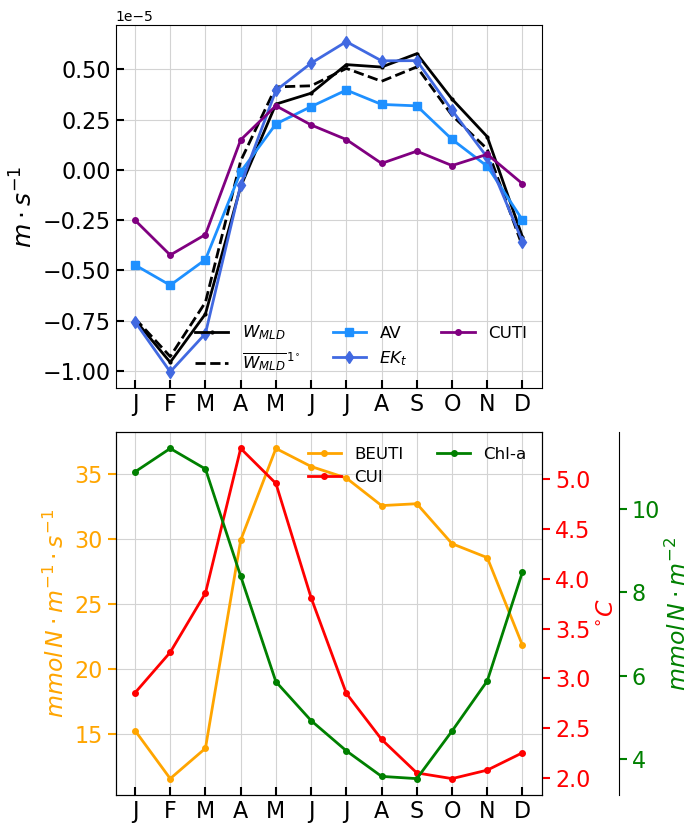

In [31]:
lsz = 4 #12 + 

# ============================================================
# Seasonal cycles
# ============================================================
wmlds  = seasonality(drop_en_events(wmld.WMLD)).mean(
    dim=('lat', 'lon')) - seasonality(drop_en_events(wmld.WMLD)).mean()

Croco_j = seasonality(drop_en_events(CROCO_j)).mean(
    dim=('lon','lat_band')) - seasonality(drop_en_events(CROCO_j)).mean()

AVs    = seasonality(drop_en_events(AV)).mean(
    dim=('lat', 'lon')) - seasonality(drop_en_events(AV)).mean()

EK_ts   = seasonality(drop_en_events(Ek_t)).mean(
    dim='lat') - seasonality(drop_en_events(Ek_t)).mean()

CUTIs  = seasonality(drop_en_events(CUTI/d)).mean(
    dim=('lat_band', 'lon')) - seasonality(drop_en_events(CUTI/d)).mean()

BEUTIs = seasonality(drop_en_events(BEUTI)).mean(dim=('lat_band', 'lon'))
CUIs   = seasonality(drop_en_events(CUI.CUI_cc)).mean(dim='lat')
CHLs   = seasonality(drop_en_events(CHL.chla)).mean(dim=('lat', 'lon'))


months = ['J','F','M','A','M','J','J','A','S','O','N','D']


def make_patch_spines_invisible(ax):
    ax.set_frame_on(True)
    ax.patch.set_visible(False)
    for sp in ax.spines.values():
        sp.set_visible(False)

# ============================================================
# Figure with two panels
# ============================================================
fig, (axL, axR_host) = plt.subplots(2, 1, figsize=(5.5, 10))

# ------------------------------------------------------------
# Upper PANEL — wind-based indices (all share m/s)
# ------------------------------------------------------------
axL.plot(wmlds.month,   wmlds,   color='black',      lw=2, marker='.', ms=4, label='$W_{MLD}$')
axL.plot(Croco_j.month, Croco_j, color='black',       lw=2, linestyle='--', ms=4, label=r'$\overline{W_{MLD}}^{\,1^{\circ}}$')
axL.plot(AVs.month,     AVs,     color='dodgerblue', lw=2, marker='s', ms=6, label='AV')
axL.plot(EK_ts.month,   EK_ts,   color='royalblue',  lw=2, marker='d', ms=6, label='$EK_t$')
axL.plot(CUTIs.month,   CUTIs,   color='purple',     lw=2, marker='o', ms=4, label='CUTI')
# axL.plot(UGEOs.month,   UGEOs,   color='teal',       lw=2, marker='^', ms=5, label='$U_{GEO}$')

axL.set_ylabel('$m \\cdot s^{-1}$', fontsize=14+lsz)
axL.set_xticks(range(1, 13))
axL.set_xticklabels(months, fontsize=12+lsz)
axL.tick_params(axis='both', labelsize=12+lsz, direction='in', size=6, width=1.5)
axL.grid(True, color='lightgrey')
axL.set_axisbelow(True)
# axL.set_title('(a) Wind-based indices', fontsize=13+lsz, loc='left', fontweight='bold')
axL.legend(fontsize=10+lsz-2, ncol=3, frameon=False, loc='lower right')
# axL.legend(fontsize=10+lsz-2, ncol=2, frameon=False, loc='best')

# ------------------------------------------------------------
# Bottom PANEL — BEUTI, CUI, Chl (different units → twin axes)
# ------------------------------------------------------------
par1 = axR_host.twinx()          # CUI (°C)
par2 = axR_host.twinx()          # Chl (mmol N m⁻²)

par2.spines["right"].set_position(("axes", 1.18))
make_patch_spines_invisible(par2)
par2.spines["right"].set_visible(True)

# --- BEUTI on host ---
BEUTi, = axR_host.plot(BEUTIs.month, BEUTIs,
                       color='orange', lw=2, marker='o', ms=4, label='BEUTI')

# --- CUI on par1 ---
CUi,   = par1.plot(CUIs.month,   CUIs,
                   color='red',    lw=2, marker='o', ms=4, label='CUI')

# --- Chl on par2 ---
Chli,  = par2.plot(CHLs.month,   CHLs,
                   color='green',  lw=2, marker='o', ms=4, label='Chl-a')

# Labels and colors
axR_host.set_ylabel('$mmol\\,N \\cdot m^{-1} \\cdot s^{-1}$', fontsize=13+lsz)
par1.set_ylabel('$^{\\circ}C$', fontsize=13+lsz)
par2.set_ylabel('$mmol\\,N \\cdot m^{-2}$', fontsize=13+lsz)

axR_host.yaxis.label.set_color('orange')
par1.yaxis.label.set_color('red')
par2.yaxis.label.set_color('green')

tkw = dict(size=6, width=1.5)
axR_host.tick_params(axis='y', colors='orange', labelsize=12+lsz, **tkw)
par1.tick_params(axis='y',     colors='red',    labelsize=12+lsz, **tkw)
par2.tick_params(axis='y',     colors='green',  labelsize=12+lsz, **tkw)
axR_host.tick_params(axis='x', labelsize=12, direction='in', **tkw)

axR_host.set_xticks(range(1, 13))
axR_host.set_xticklabels(months, fontsize=12+lsz)
axR_host.grid(True, color='lightgrey')
axR_host.set_axisbelow(True)
# axR_host.set_title('(b) SST, Chl and nutrient indices', fontsize=13, loc='left', fontweight='bold')

# Combined legend for right panel
handles, labels = [], []
for a_ in (axR_host, par1, par2):
    h, l = a_.get_legend_handles_labels()
    handles += h
    labels  += l
axR_host.legend(handles, labels, fontsize=10+lsz-2, ncol=2,frameon=False, loc='upper right')
# axL.legend(fontsize=10, ncol=3, frameon=False, loc='lower right')

# fig.suptitle('Seasonal cycle of upwelling indices', fontsize=16, y=1.02)
fig.subplots_adjust(top=0.88, hspace=0.12)

# --- Save ---
# with PdfPages('figures/Seasonal_cycle_split_3.pdf') as pdf:
#     pdf.savefig(fig, bbox_inches='tight')

plt.show()

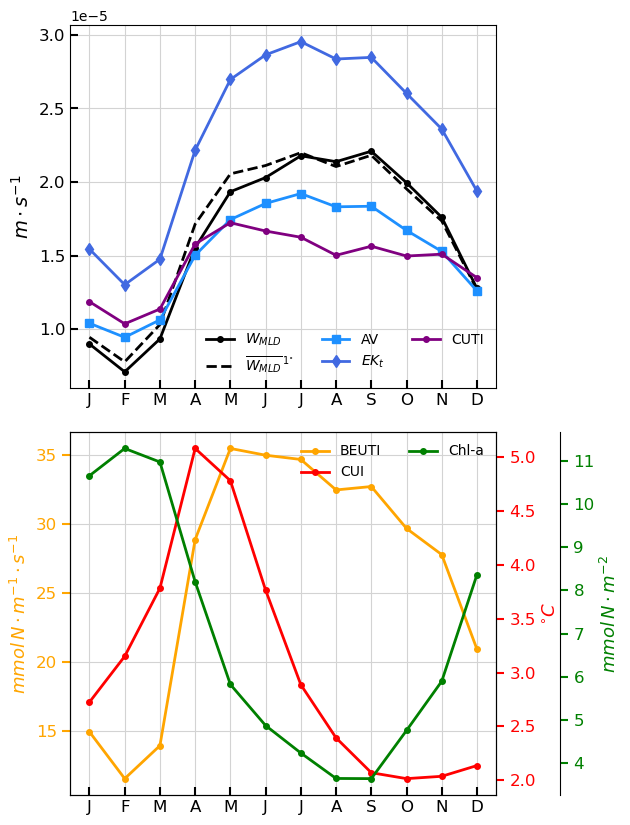

In [31]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MultipleLocator


def make_patch_spines_invisible(ax):
    ax.set_frame_on(True)
    ax.patch.set_visible(False)
    for sp in ax.spines.values():
        sp.set_visible(False)


# d = (1/12) * 10 * 111 * 1000

# ============================================================
# Seasonal cycles
# ============================================================
wmlds   = seasonality(wmld.WMLD).mean(dim=('lat', 'lon'))
Croco_j = seasonality(CROCO_j).mean(dim=('lon', 'lat_band'))
AVs     = seasonality(AV).mean(dim=('lat', 'lon'))
Ek_ts   = seasonality(Ek_t).mean(dim='lat')
CUTIs   = seasonality(CUTI/d).mean(dim=('lat_band', 'lon')) 
UGEOs   = seasonality(UGEO/d).mean(dim=('lat_band', 'lon'))

BEUTIs  = seasonality(BEUTI).mean(dim=('lat_band', 'lon'))
CUIs    = seasonality(CUI.CUI_cc).mean(dim='lat')
CHLs    = seasonality(CHL.chla).mean(dim=('lat', 'lon'))

months = ['J','F','M','A','M','J','J','A','S','O','N','D']


def make_patch_spines_invisible(ax):
    ax.set_frame_on(True)
    ax.patch.set_visible(False)
    for sp in ax.spines.values():
        sp.set_visible(False)


# ============================================================
# Figure with two panels
# ============================================================
fig, (axL, axR_host) = plt.subplots(2, 1, figsize=(5.5, 10))

# ------------------------------------------------------------
# Upper PANEL — wind-based indices (all share m/s)
# ------------------------------------------------------------
axL.plot(wmlds.month,   wmlds,   color='black',      lw=2, marker='o', ms=4, label='$W_{MLD}$')
axL.plot(Croco_j.month, Croco_j, color='black',       lw=2, linestyle='--', ms=4, label=r'$\overline{W_{MLD}}^{\,1^{\circ}}$')
axL.plot(AVs.month,     AVs,     color='dodgerblue', lw=2, marker='s', ms=6, label='AV')
axL.plot(Ek_ts.month,   Ek_ts,   color='royalblue',  lw=2, marker='d', ms=6, label='$EK_t$')
axL.plot(CUTIs.month,   CUTIs,   color='purple',     lw=2, marker='o', ms=4, label='CUTI')
# axL.plot(UGEOs.month,   UGEOs,   color='teal',       lw=2, marker='^', ms=5, label='$U_{GEO}$')

axL.set_ylabel('$m \\cdot s^{-1}$', fontsize=14)
axL.set_xticks(range(1, 13))
axL.set_xticklabels(months, fontsize=12)
axL.tick_params(axis='both', labelsize=12, direction='in', size=6, width=1.5)
axL.grid(True, color='lightgrey')
axL.set_axisbelow(True)
# axL.set_title('(a) Wind-based indices', fontsize=13, loc='left', fontweight='bold')
axL.legend(fontsize=10, ncol=3, frameon=False, loc='lower right')

# ------------------------------------------------------------
# Bottom PANEL — BEUTI, CUI, Chl (different units → twin axes)
# ------------------------------------------------------------
par1 = axR_host.twinx()          # CUI (°C)
par2 = axR_host.twinx()          # Chl (mmol N m⁻²)

par2.spines["right"].set_position(("axes", 1.15))
make_patch_spines_invisible(par2)
par2.spines["right"].set_visible(True)

# --- BEUTI on host ---
BEUTi, = axR_host.plot(BEUTIs.month, BEUTIs,
                       color='orange', lw=2, marker='o', ms=4, label='BEUTI')

# --- CUI on par1 ---
CUi,   = par1.plot(CUIs.month,   CUIs,
                   color='red',    lw=2, marker='o', ms=4, label='CUI')

# --- Chl on par2 ---
Chli,  = par2.plot(CHLs.month,   CHLs,
                   color='green',  lw=2, marker='o', ms=4, label='Chl-a')

# Labels and colors
axR_host.set_ylabel('$mmol\\,N \\cdot m^{-1} \\cdot s^{-1}$', fontsize=13)
par1.set_ylabel('$^{\\circ}C$', fontsize=13)
par2.set_ylabel('$mmol\\,N \\cdot m^{-2}$', fontsize=13)

axR_host.yaxis.label.set_color('orange')
par1.yaxis.label.set_color('red')
par2.yaxis.label.set_color('green')

tkw = dict(size=6, width=1.5)
axR_host.tick_params(axis='y', colors='orange', labelsize=12, **tkw)
par1.tick_params(axis='y',     colors='red',    labelsize=12, **tkw)
par2.tick_params(axis='y',     colors='green',  labelsize=12, **tkw)
axR_host.tick_params(axis='x', labelsize=12, direction='in', **tkw)

axR_host.set_xticks(range(1, 13))
axR_host.set_xticklabels(months, fontsize=12)
axR_host.grid(True, color='lightgrey')
axR_host.set_axisbelow(True)
# axR_host.set_title('(b) SST, Chl and nutrient indices', fontsize=13, loc='left', fontweight='bold')

# Combined legend for right panel
handles, labels = [], []
for a_ in (axR_host, par1, par2):
    h, l = a_.get_legend_handles_labels()
    handles += h
    labels  += l
axR_host.legend(handles, labels, fontsize=10, ncol=2,frameon=False, loc='upper right')
# axL.legend(fontsize=10, ncol=3, frameon=False, loc='lower right')

# fig.suptitle('Seasonal cycle of upwelling indices', fontsize=16, y=1.02)
fig.subplots_adjust(top=0.88, hspace=0.12)

# --- Save ---
# with PdfPages('figures/Seasonal_cycle_split_2.pdf') as pdf:
#     pdf.savefig(fig, bbox_inches='tight')

plt.show()

Text(0.5, 1.0, '$UI - CROCO$')

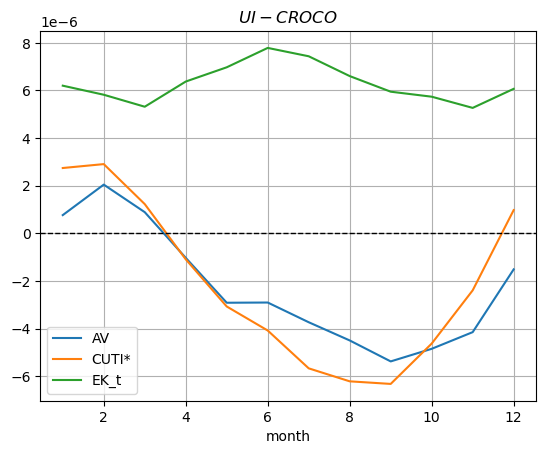

In [32]:
seasonality(drop_en_events(AV)-drop_en_events(wmld.WMLD)).mean(dim=('lon','lat')).plot(label='AV')
seasonality(drop_en_events((CUTI/d))-drop_en_events(CROCO_j)).mean(dim=('lon','lat_band')).plot(label='CUTI*')
seasonality(drop_en_events(Ek_t)-drop_en_events(wmld.WMLD).mean('lon')).mean('lat').plot(label='EK_t')
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.legend()
plt.grid(True)
plt.title('$UI - CROCO$')

## Inter-annual variability

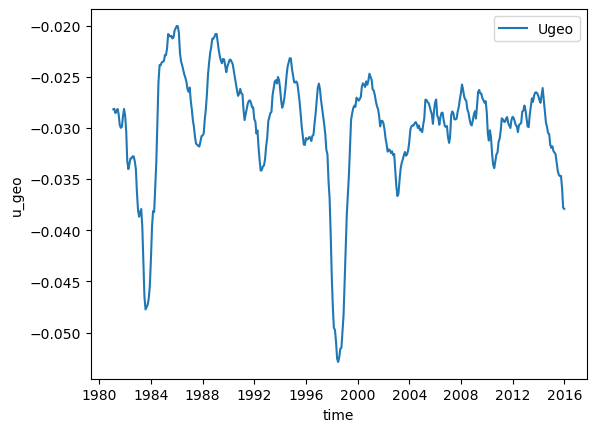

In [33]:
(ugeo).mean(dim=('lat_band')).rolling(time=13).mean().plot(label='Ugeo')
plt.legend()

Text(0.5, 1.0, 'Wind based')

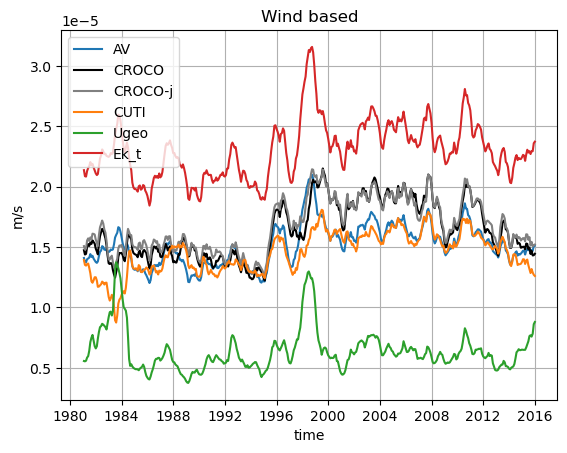

In [34]:
AV.mean(dim=('lon','lat')).rolling(time=13).mean().plot(label='AV')
wmld.WMLD.mean(dim=('lon','lat')).rolling(time=13).mean().plot(label='CROCO',color='Black')
CROCO_j.mean(dim=('lon','lat_band')).rolling(time=13).mean().plot(label='CROCO-j',color='gray')

(CUTI/d).mean(dim=('lon','lat_band')).rolling(time=13).mean().plot(label='CUTI')
(UGEO/d*-1).mean(dim=('lon','lat_band')).rolling(time=13).mean().plot(label='Ugeo')

Ek_t.mean('lat').rename('m/s').rolling(time=13).mean().plot(label='Ek_t')

# seasonality(Pumping).mean(dim=('lon','lat')).plot(label='$Ek_{pumping}$')

plt.legend()
plt.grid(True)
plt.title('Wind based')

## Normal conditions

* We remove the seasonal cycle and high frequencies with a low-pass filter, and the EN were removed

In [35]:
import datetime

NINO = [
    (datetime.datetime(1982, 8, 1), datetime.datetime(1983, 12, 31)),
    (datetime.datetime(1997, 4, 1), datetime.datetime(1998, 7, 30)),
]

def drop_en_events(da, en_windows=NINO, dim='time'):
    """Mask out El Niño periods from a time series."""
    mask = np.ones(da.sizes[dim], dtype=bool)
    time = da[dim].values
    for start, end in en_windows:
        start64 = np.datetime64(start)
        end64   = np.datetime64(end)
        mask &= ~((time >= start64) & (time <= end64))
    return da.isel({dim: mask})

In [36]:
from scipy.stats import pearsonr, spearmanr

def prep_for_taylor(da, dim='time', window=13, drop_en=True):
    """Climatology removal → running mean → drop NaNs → optionally drop EN."""
    clim = da.groupby(f'{dim}.month').mean(dim=dim)
    anom = da.groupby(f'{dim}.month') - clim
    smooth = anom.rolling({dim: window}, center=True).mean().dropna(dim=dim)
    if drop_en:
        smooth = drop_en_events(smooth)
    return smooth

def taylor_skill(std_norm, corr):
    return (4 * (1 + corr)**4) / ((std_norm + 1/std_norm)**2 * (1 + 1)**4)

def lagged_correlation(test, ref, max_lag=6):
    """
    Find the lag (in months) that maximizes |Pearson correlation|.
    Positive lag: test lags reference (test responds after ref).
    Negative lag: test leads reference.
    """
    t = np.asarray(test).ravel()
    r = np.asarray(ref).ravel()
    mask = np.isfinite(t) & np.isfinite(r)
    t, r = t[mask], r[mask]

    lags = np.arange(-max_lag, max_lag + 1)
    corrs = []
    for lag in lags:
        if lag < 0:
            # test leads: shift test forward
            tt, rr = t[:lag], r[-lag:]
        elif lag > 0:
            # test lags: shift test backward
            tt, rr = t[lag:], r[:-lag]
        else:
            tt, rr = t, r
        corrs.append(np.corrcoef(tt, rr)[0, 1])

    corrs = np.array(corrs)
    # Pick the lag with maximum absolute correlation (handles anti-correlation)
    best_idx = np.argmax(np.abs(corrs))
    return lags[best_idx], corrs[best_idx]

In [37]:

# Prepare all series
wmld_ts   = prep_for_taylor(wmld.WMLD.mean(dim=('lat','lon')))
CROCO_j_ts = prep_for_taylor(CROCO_j.mean(dim=('lon','lat_band')))

AV_ts   = prep_for_taylor(AV.mean(dim=('lat','lon')))
Ekt_ts  = prep_for_taylor(Ek_t.mean('lat'))
CUTI_ts = prep_for_taylor((CUTI/d).mean(dim=('lon','lat_band')))

BEUTI_ts = prep_for_taylor(BEUTI.mean(dim=('lon','lat_band')))
CUI_ts   = prep_for_taylor(CUI.CUI_cc.mean('lat'))
CHL_ts   = prep_for_taylor(CHL.chla.mean(dim=('lat','lon')))

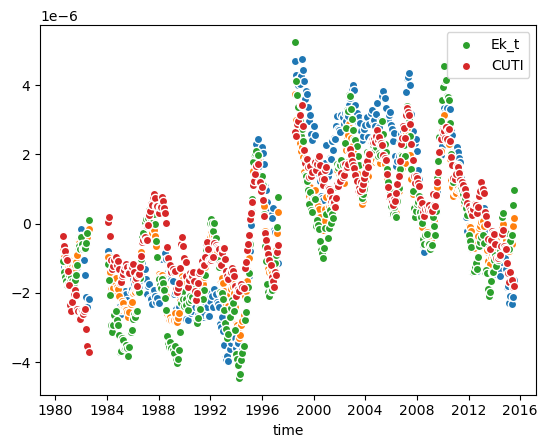

In [38]:
wmld_ts.plot.scatter()
AV_ts.plot.scatter()
Ekt_ts.plot.scatter(label='Ek_t')
CUTI_ts.plot.scatter(label='CUTI')
plt.legend()

In [39]:
# Group 1: Dynamical indices (same units as W_mld)
dynamical_pairs = {
    'AV':    (AV_ts,    wmld_ts),
    'EK_t':  (Ekt_ts,   wmld_ts),
    'CUTI*': (CUTI_ts,  CROCO_j_ts),
}

# Group 2: Proxy indices (correlation only)
proxy_pairs = {
    'BEUTI*': (BEUTI_ts, CROCO_j_ts),
    'CUI':   (CUI_ts,   wmld_ts),
    'Chl':   (CHL_ts,   wmld_ts),
}

In [40]:
## for Winds
dyn_rows = []
for name, (test, ref) in dynamical_pairs.items():
    std_t, std_r, corr, rmse = taylor_stats(test.values, ref.values)
    std_norm = std_t / std_r
    dyn_rows.append({
        'name': name,
        'corr': corr,
        'std_norm': std_norm,
        'rmse_norm': rmse / std_r,
        'taylor_skill': taylor_skill(std_norm, corr),
    })

dyn_df = pd.DataFrame(dyn_rows).set_index('name').sort_values('taylor_skill', ascending=False)
print("=== Dynamical indices ===")
print(dyn_df.round(3))


# --- Proxy indices with lag ---
proxy_rows = []
for name, (test, ref) in proxy_pairs.items():
    t = test.values.ravel()
    r = ref.values.ravel()
    mask = np.isfinite(t) & np.isfinite(r)
    t, r = t[mask], r[mask]

    pearson_0  = pearsonr(t, r)[0]
    spearman_0 = spearmanr(t, r)[0]
    best_lag, best_corr = lagged_correlation(t, r, max_lag=6)

    proxy_rows.append({
        'name':         name,
        'pearson':      pearson_0,
        'spearman':     spearman_0,
        'best_lag_mo':  best_lag,
        'corr_at_lag':  best_corr,
    })

proxy_df = pd.DataFrame(proxy_rows).set_index('name')
print("\n=== Proxy indices ===")
print(proxy_df.round(3))

=== Dynamical indices ===
        corr  std_norm  rmse_norm  taylor_skill
name                                           
EK_t   0.867     0.868      0.499         0.744
AV     0.906     0.656      0.492         0.694
CUTI*  0.861     0.730      0.525         0.681

=== Proxy indices ===
        pearson  spearman  best_lag_mo  corr_at_lag
name                                               
BEUTI*    0.787     0.822            0        0.787
CUI      -0.085    -0.141           -6       -0.199
Chl      -0.692    -0.723            3       -0.697


In [41]:
# Compute stats for each pair
rows = []
for name, (test, ref) in dynamical_pairs.items():
    std_t, std_r, corr, rmse = taylor_stats(test.values, ref.values)
    rows.append({
        'name':     name,
        'std_test': std_t,
        'std_ref':  std_r,
        'corr':     corr,
        'rmse':     rmse,
        'std_norm': std_t / std_r,   # normalized std (test / reference)
    })

stats_df = pd.DataFrame(rows).set_index('name')
print(stats_df.to_string(float_format='{:.3e}'.format))

       std_test   std_ref      corr      rmse  std_norm
name                                                   
AV    1.520e-06 2.317e-06 9.058e-01 1.139e-06 6.563e-01
EK_t  2.011e-06 2.317e-06 8.666e-01 1.156e-06 8.682e-01
CUTI* 1.526e-06 2.090e-06 8.612e-01 1.097e-06 7.304e-01


* "Optimal lags for the dynamical indices fall within ±1 month of zero, with correlation improvements below 0.03, confirming that wind-based indices respond to the same instantaneous forcing as W_mld with no meaningful phase offset."
* The fact that the lag increases |r| from 0.42 to 0.49 at +5 months is also meaningful — it suggests there's a delayed biological response, but the delay plus sign flip means Chl is not a good proxy for physical upwelling
* CUI: r = -0.045 with Pearson, -0.098 with Spearman — essentially zero. The "best lag" at -6 months giving r = -0.166 is meaningless; that's just the edge of your search window and the correlation is still near zero. This is a null result, not a signal.
*  These results emphasize that BEUTI is the only biogeochemical proxy that tracks W_mld variability faithfully in this region, while SST- and Chl-based indices reflect distinct physical and ecological processes.


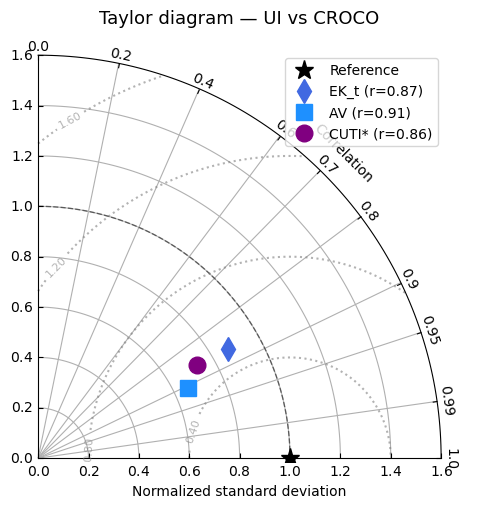

In [42]:
plot_taylor(
    dyn_df,
    title='Taylor diagram — UI vs CROCO',
    # savepath='figures/taylor_diagram_winds_normal_conditions.pdf',
)

## Now EN

In [43]:
def prep_for_taylor(da, dim='time', window=13, drop_en=False):
    """Climatology removal → running mean → drop NaNs → optionally drop EN."""
    clim = da.groupby(f'{dim}.month').mean(dim=dim)
    anom = da.groupby(f'{dim}.month') - clim
    smooth = anom.rolling({dim: window}, center=True).mean().dropna(dim=dim)
    if drop_en:
        smooth = drop_en_events(smooth)
    return smooth

In [44]:
# Prepare all series
wmld_ts   = prep_for_taylor(wmld.WMLD.mean(dim=('lat','lon')))
CROCO_j_ts = prep_for_taylor(CROCO_j.mean(dim=('lon','lat_band')))

AV_ts   = prep_for_taylor(AV.mean(dim=('lat','lon')))
Ekt_ts  = prep_for_taylor(Ek_t.mean('lat'))
CUTI_ts = prep_for_taylor((CUTI/d).mean(dim=('lon','lat_band')))

BEUTI_ts = prep_for_taylor(BEUTI.mean(dim=('lon','lat_band')))
CUI_ts   = prep_for_taylor(CUI.CUI_cc.mean('lat'))
CHL_ts   = prep_for_taylor(CHL.chla.mean(dim=('lat','lon')))

### Scatter plots

In [45]:
# Group 1: Dynamical indices (same units as W_mld)
dynamical_pairs = {
    'AV':    (AV_ts,    wmld_ts),
    'EK_t':  (Ekt_ts,   wmld_ts),
    'CUTI*': (CUTI_ts,  CROCO_j_ts),
}

# Group 2: Proxy indices (correlation only)
proxy_pairs = {
    'BEUTI': (BEUTI_ts, CROCO_j_ts),
    'CUI':   (CUI_ts,   wmld_ts),
    'Chl':   (CHL_ts,   wmld_ts),
}

In [46]:
all_UI = dynamical_pairs | proxy_pairs
# all_UI

In [47]:
CHL_ts['time'] = wmld_ts.time
# CHL_ts['time']

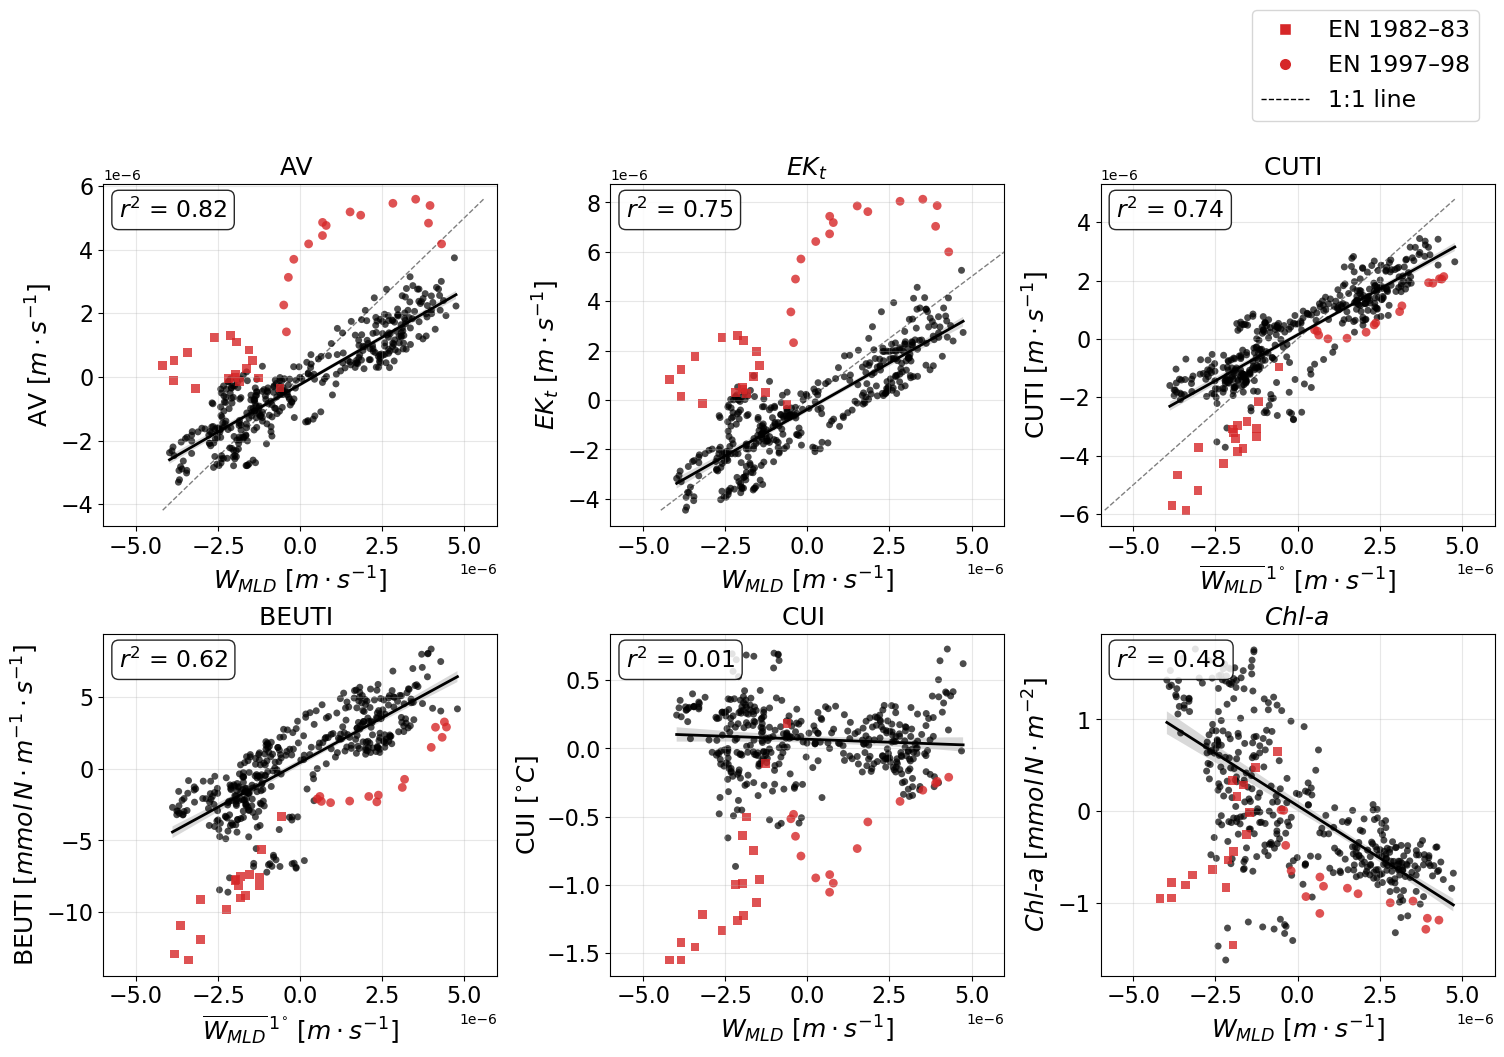

In [48]:
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.stats import pearsonr

lsz = 6

EN1 = (pd.Timestamp('1982-08-01'), pd.Timestamp('1983-12-31'))
EN2 = (pd.Timestamp('1997-04-01'), pd.Timestamp('1998-06-30'))

BASE_COLORS = {
    'AV':    'black',
    'EK_t':  'black',
    'CUTI':  'black',
    'BEUTI': 'black',
    'CUI':   'black',
    'Chl':   'black',
}

UNITS = {
    'AV':    r'$m \cdot s^{-1}$',
    'EK_t':  r'$m \cdot s^{-1}$',
    'CUTI':  r'$m \cdot s^{-1}$',
    'BEUTI': r'$mmol\,N \cdot m^{-1} \cdot s^{-1}$',
    'CUI':   r'$^{\circ}C$',
    'Chl':   r'$mmol\,N \cdot m^{-2}$',
}

REF_UNITS = {
    'AV':    r'$W_{MLD}$ [$m \cdot s^{-1}$]',
    'EK_t':  r'$W_{MLD}$ [$m \cdot s^{-1}$]',
    'CUTI':  r'$\overline{W_{MLD}}^{\,1^{\circ}}$ [$m \cdot s^{-1}$]',
    'BEUTI': r'$\overline{W_{MLD}}^{\,1^{\circ}}$ [$m \cdot s^{-1}$]',
    'CUI':   r'$W_{MLD}$ [$m \cdot s^{-1}$]',
    'Chl':   r'$W_{MLD}$ [$m \cdot s^{-1}$]',
}

TITLE_LABELS = {
    'AV':    'AV',
    'EK_t':  r'$EK_t$',
    'CUTI':  'CUTI',
    'BEUTI': 'BEUTI',
    'CUI':   'CUI',
    'Chl':   r'$Chl\text{-}a$',
}

ONE_TO_ONE = ['AV', 'EK_t', 'CUTI']


def _align_pair(test, ref):
    t, r = xr.align(test, ref, join='inner')
    df = pd.DataFrame({
        'time': pd.to_datetime(t.time.values),
        'test': t.values.ravel(),
        'ref':  r.values.ravel(),
    }).dropna()
    return df


def _en_masks(time_series):
    t = pd.to_datetime(time_series)
    en1 = (t >= EN1[0]) & (t <= EN1[1])
    en2 = (t >= EN2[0]) & (t <= EN2[1])
    return en1.to_numpy(), en2.to_numpy()


def plot_scatter_matrix(pairs, ncols=3, title=None,
                        xlim=None, savepath=None):
    n = len(pairs)
    nrows = int(np.ceil(n / ncols))

    fig, axs = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows),
                            constrained_layout=True)
    axs = np.atleast_1d(axs).flatten()

    for ax, (name, (test, ref)) in zip(axs, pairs.items()):
        df = _align_pair(test, ref)
        if df.empty:
            ax.axis('off')
            continue

        en1, en2 = _en_masks(df['time'])
        non_en = ~(en1 | en2)

        x = df['ref'].to_numpy()
        y = df['test'].to_numpy()

        # Non-EN points: black circles
        ax.scatter(x[non_en], y[non_en], c='black', marker='o',
                   edgecolors='none', s=25, alpha=0.7, label='Non-EN')

        # EN 1982-83: red squares
        if en1.sum() > 0:
            ax.scatter(x[en1], y[en1], c='tab:red', marker='s',
                       edgecolors='none', s=40, alpha=0.8, label='EN 1982–83')

        # EN 1997-98: red circles
        if en2.sum() > 0:
            ax.scatter(x[en2], y[en2], c='tab:red', marker='o',
                       edgecolors='none', s=40, alpha=0.8, label='EN 1997–98')

        # Regression on non-EN points only
        try:
            sns.regplot(
                x=x[non_en], y=y[non_en], ax=ax, ci=95, scatter=False,
                line_kws={'color': 'black', 'lw': 2},
            )
            r, _ = pearsonr(x[non_en], y[non_en])
            label = f"$r^2$ = {r**2:.2f}"
        except Exception:
            label = "$r^2$ n/a"

        # 1:1 line
        if name in ONE_TO_ONE:
            lims = [min(x.min(), y.min()), max(x.max(), y.max())]
            ax.plot(lims, lims, 'k--', lw=1, alpha=0.5, zorder=0)

        ax.text(0.04, 0.96, label,
                transform=ax.transAxes, va='top', ha='left', fontsize=11 + lsz,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

        # Labels with units
        title_name = TITLE_LABELS.get(name, name)
        unit = UNITS.get(name, '')
        ref_label = REF_UNITS.get(name, r'$W_{MLD}$')

        ax.set_xlabel(ref_label, fontsize=12 + lsz)
        ax.set_ylabel(f'{title_name} [{unit}]', fontsize=12 + lsz)
        ax.set_title(f'{title_name} ', fontsize=12 + lsz)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=10 + lsz)

        if xlim is not None:
            ax.set_xlim(xlim)

    for ax in axs[n:]:
        ax.axis('off')

    # Legend
    legend_elems = [
        # Line2D([0], [0], marker='o', color='w', markerfacecolor='black',
        #        markersize=9, label='Non-EN'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='tab:red',
               markersize=9, label='EN 1982–83'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:red',
               markersize=9, label='EN 1997–98'),
    ]
    if any(name in ONE_TO_ONE for name in pairs):
        legend_elems.append(
            Line2D([0], [0], color='k', linestyle='--', lw=1, label='1:1 line')
        )

    fig.legend(handles=legend_elems, loc='lower right',
               bbox_to_anchor=(0.99, 1.02), frameon=True, fontsize=11 + lsz)

    if title:
        fig.suptitle(title, fontsize=14 + lsz, y=1.04)

    if savepath:
        plt.savefig(savepath, bbox_inches='tight', dpi=300)

    return fig, axs


# ============================================================
# Usage
# ============================================================
all_pairs = {
    'AV':    (AV_ts,    wmld_ts),
    'EK_t':  (Ekt_ts,   wmld_ts),
    'CUTI':  (CUTI_ts,  CROCO_j_ts),
    'BEUTI': (BEUTI_ts, CROCO_j_ts),
    'CUI':   (CUI_ts,   wmld_ts),
    'Chl':   (CHL_ts,   wmld_ts),
}

fig, axs = plot_scatter_matrix(
    all_pairs,
    ncols=3,
    xlim=(-6e-6, 6e-6),
    # title='Upwelling indices vs CROCO (interannual, EN excluded from fit)',
    # savepath='figures/scatter_all.pdf',
)
plt.show()

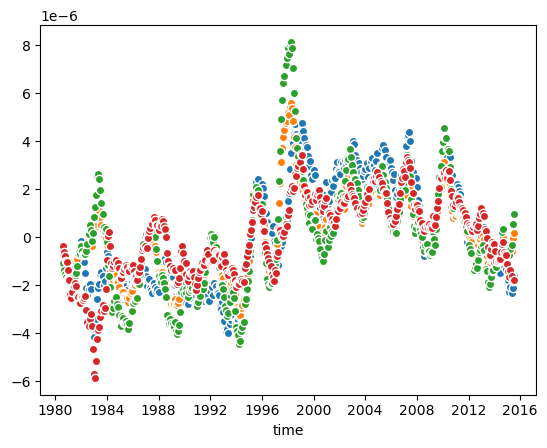

In [49]:
wmld_ts.plot.scatter()
AV_ts.plot.scatter()
Ekt_ts.plot.scatter()
CUTI_ts.plot.scatter()

## Taylor skill

In [50]:
## for Winds
dyn_rows = []
for name, (test, ref) in dynamical_pairs.items():
    std_t, std_r, corr, rmse = taylor_stats(test.values, ref.values)
    std_norm = std_t / std_r
    dyn_rows.append({
        'name': name,
        'corr': corr,
        'std_norm': std_norm,
        'rmse_norm': rmse / std_r,
        'taylor_skill': taylor_skill(std_norm, corr),
    })

dyn_df = pd.DataFrame(dyn_rows).set_index('name').sort_values('taylor_skill', ascending=False)
print("=== Dynamical indices ===")
print(dyn_df.round(3))


# --- Proxy indices with lag ---
proxy_rows = []
for name, (test, ref) in proxy_pairs.items():
    t = test.values.ravel()
    r = ref.values.ravel()
    mask = np.isfinite(t) & np.isfinite(r)
    t, r = t[mask], r[mask]

    pearson_0  = pearsonr(t, r)[0]
    spearman_0 = spearmanr(t, r)[0]
    best_lag, best_corr = lagged_correlation(t, r, max_lag=6)

    proxy_rows.append({
        'name':         name,
        'pearson':      pearson_0,
        'spearman':     spearman_0,
        'best_lag_mo':  best_lag,
        'corr_at_lag':  best_corr,
    })

proxy_df = pd.DataFrame(proxy_rows).set_index('name')
print("\n=== Proxy indices ===")
print(proxy_df.round(3))

=== Dynamical indices ===
        corr  std_norm  rmse_norm  taylor_skill
name                                           
CUTI*  0.841     0.788      0.544         0.679
AV     0.804     0.731      0.600         0.600
EK_t   0.737     1.008      0.728         0.569

=== Proxy indices ===
       pearson  spearman  best_lag_mo  corr_at_lag
name                                              
BEUTI    0.747     0.793            0        0.747
CUI      0.064    -0.084            3        0.076
Chl     -0.637    -0.648            0       -0.637


In [51]:
# Compute stats for each pair
rows = []
for name, (test, ref) in dynamical_pairs.items():
    std_t, std_r, corr, rmse = taylor_stats(test.values, ref.values)
    rows.append({
        'name':     name,
        'std_test': std_t,
        'std_ref':  std_r,
        'corr':     corr,
        'rmse':     rmse,
        'std_norm': std_t / std_r,   # normalized std (test / reference)
    })

stats_df = pd.DataFrame(rows).set_index('name')
print(stats_df.to_string(float_format='{:.3e}'.format))

       std_test   std_ref      corr      rmse  std_norm
name                                                   
AV    1.700e-06 2.326e-06 8.035e-01 1.394e-06 7.312e-01
EK_t  2.343e-06 2.326e-06 7.373e-01 1.692e-06 1.008e+00
CUTI* 1.682e-06 2.135e-06 8.410e-01 1.161e-06 7.878e-01


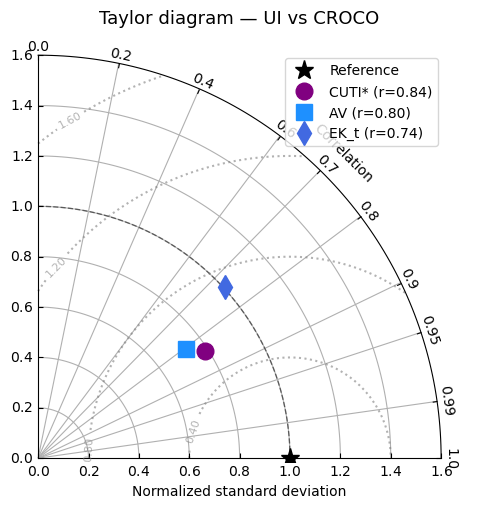

In [52]:
plot_taylor(
    dyn_df,
    title='Taylor diagram — UI vs CROCO',
    # savepath='figures/taylor_diagram_winds_with_EN.pdf',
)

## Amplitude of drivers

In [53]:
SST = xr.open_dataset('SST.nc').compute()
SST= SST.where(SST.SST!=0,np.nan)


mask = coastal_band_mask(SST,'SST',10).sel(lon=slice(-85,None),lat=slice(-16,-5))
SST = SST.where(mask).SST

SSTs   = prep_for_taylor(SST.mean(dim=('lat','lon')), dim='time', window=13, drop_en=False)
SSTs

<xarray.DataArray 'SST' (time: 420)> Size: 2kB
array([ 1.89503446e-01,  1.54946700e-01,  1.68138221e-01,  2.37923563e-01,
        1.68451309e-01,  1.66121557e-01,  1.87593460e-01,  2.14861810e-01,
        1.68728098e-01,  1.30947262e-01,  4.41364907e-02, -1.27680860e-02,
       -1.79195404e-02,  1.52579531e-01,  3.53829920e-01,  4.89282489e-01,
        4.64624584e-01,  4.55443919e-01,  4.69499767e-01,  5.16245961e-01,
        6.13582313e-01,  7.90412724e-01,  1.06978142e+00,  1.52031302e+00,
        1.92672646e+00,  2.19695544e+00,  2.31902933e+00,  2.74936008e+00,
        3.22138500e+00,  3.71176338e+00,  4.00630569e+00,  4.10297823e+00,
        4.04887819e+00,  3.98709822e+00,  3.89501214e+00,  3.70558023e+00,
        3.35833287e+00,  2.94933391e+00,  2.68132949e+00,  2.43863893e+00,
        1.83594906e+00,  1.23723459e+00,  7.06817925e-01,  3.76853585e-01,
        2.09595397e-01,  1.73398912e-01,  1.26035333e-01,  6.15604855e-02,
       -6.48918897e-02, -2.39153132e-01, -2.49955043e-01, -3.72763932e-01,
       -4.35284764e-01, -3.99195105e-01, -3.78765106e-01, -4.13421571e-01,
       -4.81950104e-01, -5.33383191e-01, -5.84207118e-01, -6.49669647e-01,
       -7.13785946e-01, -6.95319414e-01, -6.73349559e-01, -7.27162898e-01,
       -6.72982633e-01, -6.32234454e-01, -5.96603394e-01, -5.17679334e-01,
       -4.25332308e-01, -3.36097360e-01, -3.21796149e-01, -3.04977268e-01,
       -2.00372264e-01, -1.57884747e-01, -1.35561734e-01,  2.12466903e-02,
        1.91249415e-01,  3.10277671e-01,  4.21510279e-01,  4.84640419e-01,
...
       -2.26028152e-02, -6.59254566e-02, -5.56199737e-02, -7.97965005e-02,
       -6.63636327e-02, -3.91221419e-02, -1.80930287e-01, -3.55543673e-01,
       -4.08926994e-01, -3.77991974e-01, -4.36570853e-01, -5.14412880e-01,
       -5.89649677e-01, -6.89624965e-01, -7.72656381e-01, -8.81400526e-01,
       -9.13435042e-01, -8.92893136e-01, -9.85692143e-01, -9.84827101e-01,
       -1.01278651e+00, -1.00746250e+00, -1.02191222e+00, -9.46360111e-01,
       -8.67044926e-01, -8.08618307e-01, -7.49927163e-01, -7.41671741e-01,
       -7.12357521e-01, -6.35690033e-01, -6.21145785e-01, -4.63277757e-01,
       -3.20528418e-01, -2.10808322e-01, -1.75704598e-01, -1.42754272e-01,
       -1.03722580e-01, -8.35759863e-02, -8.08997527e-02, -8.59764591e-02,
       -5.06472252e-02,  5.61182350e-02,  4.34951074e-02, -9.31552798e-02,
       -2.37425372e-01, -3.29811335e-01, -4.11327809e-01, -4.96192873e-01,
       -5.09844899e-01, -5.58481634e-01, -5.73300242e-01, -5.15847504e-01,
       -3.76011431e-01, -3.67785037e-01, -4.59903210e-01, -5.28423250e-01,
       -4.32235956e-01, -2.99600244e-01, -1.76456675e-01, -6.03639185e-02,
        3.11340205e-02,  6.06968962e-02,  8.87977928e-02,  7.57584199e-02,
       -2.57875007e-02, -6.57250360e-02,  1.57710001e-01,  3.22625965e-01,
        4.41089928e-01,  5.77170908e-01,  6.59888506e-01,  7.03365207e-01,
        7.51213968e-01,  8.10540318e-01,  9.34881270e-01,  1.07885325e+00],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-07-31 1980-08-31 ... 2015-06-30
    month    (time) int64 3kB 7 8 9 10 11 12 1 2 3 4 ... 9 10 11 12 1 2 3 4 5 6

In [54]:
prep_for_taylor?

Signature: prep_for_taylor(da, dim='time', window=13, drop_en=False)
Docstring: Climatology removal → running mean → drop NaNs → optionally drop EN.
File:      /tmp/ipykernel_499658/2492803310.py
Type:      function

In [55]:
SSH = xr.open_dataset('SSH.nc').compute()
SSH= SSH.where(SSH.SSH!=0,np.nan)
SSH = SSH.where(mask).SSH

SSHs   = prep_for_taylor(SSH.mean(dim=('lat','lon')), dim='time', window=13, drop_en=False)
SSHs

<xarray.DataArray 'SSH' (time: 420)> Size: 2kB
array([ 1.90531388e-02,  1.66333299e-02,  1.66195724e-02,  1.59994047e-02,
        1.46841872e-02,  1.49944359e-02,  1.22804334e-02,  8.66806787e-03,
        4.83980682e-03,  3.04258522e-03, -2.70111079e-04, -7.10432359e-04,
        3.95054743e-03,  1.56191913e-02,  2.43552495e-02,  2.80576032e-02,
        2.92273201e-02,  2.88147759e-02,  2.98997536e-02,  3.40349302e-02,
        4.12779413e-02,  4.86900359e-02,  6.15397841e-02,  7.96618089e-02,
        9.12422985e-02,  9.56786796e-02,  9.43139121e-02,  1.04700677e-01,
        1.19444139e-01,  1.33085862e-01,  1.39240369e-01,  1.39963701e-01,
        1.35958046e-01,  1.31023645e-01,  1.25759721e-01,  1.12927765e-01,
        9.41423103e-02,  8.06071535e-02,  7.03974962e-02,  6.05696924e-02,
        4.15524915e-02,  2.12038700e-02,  4.32904670e-03, -5.16088726e-03,
       -1.07573839e-02, -1.34078292e-02, -1.55070685e-02, -1.99685991e-02,
       -2.34417897e-02, -2.75513213e-02, -3.01033035e-02, -3.40006426e-02,
       -3.74153852e-02, -3.68884169e-02, -3.56038213e-02, -3.81035991e-02,
       -4.20730039e-02, -4.45497558e-02, -4.65812571e-02, -5.10880835e-02,
       -5.16439341e-02, -5.03907166e-02, -4.74600978e-02, -4.60145995e-02,
       -4.11363840e-02, -3.53749357e-02, -3.11718322e-02, -2.64387019e-02,
       -2.14675944e-02, -1.61868855e-02, -1.48030650e-02, -1.28284907e-02,
       -6.51232945e-03, -5.05495165e-03,  2.55812251e-04,  4.64962190e-03,
        7.68277887e-03,  8.11840501e-03,  1.01844994e-02,  1.01585668e-02,
...
        6.70002075e-03,  5.77918859e-03,  6.37904601e-03,  7.06378184e-03,
        9.94504150e-03,  1.29944552e-02,  1.05188740e-02,  7.95893557e-03,
        6.43136539e-03,  3.67194368e-03, -2.23920611e-03, -6.07852452e-03,
       -9.99643095e-03, -1.33487359e-02, -1.56340711e-02, -1.86267011e-02,
       -2.13288106e-02, -2.29130723e-02, -2.68375799e-02, -2.36999970e-02,
       -2.02191770e-02, -1.66718829e-02, -1.28157670e-02, -8.98067467e-03,
       -7.81802833e-03, -7.41334539e-03, -8.20472930e-03, -1.00067137e-02,
       -1.02160210e-02, -1.04550850e-02, -1.14608090e-02, -7.39787566e-03,
       -6.22350676e-03, -6.08109683e-03, -6.00539381e-03, -6.44994387e-03,
       -4.04240470e-03, -1.31761201e-03,  9.53487819e-04,  3.01708491e-03,
        4.80582053e-03,  7.84939993e-03,  1.14277788e-02,  1.13240322e-02,
        8.00012518e-03,  2.99004652e-03, -1.86176260e-03, -6.28925767e-03,
       -7.29409186e-03, -9.52131208e-03, -1.09499088e-02, -1.07419705e-02,
       -7.23010441e-03, -7.47364806e-03, -1.00653516e-02, -1.25927124e-02,
       -9.50469356e-03, -6.16197521e-03, -4.12974646e-03, -2.75127706e-03,
       -2.62969942e-03, -2.86184531e-03, -1.11290650e-03, -1.11818888e-04,
        7.85676355e-04,  1.09682814e-03,  5.31018013e-03,  9.23829060e-03,
        1.23039726e-02,  1.56158376e-02,  1.73284207e-02,  1.89021491e-02,
        2.33884193e-02,  2.99174022e-02,  3.54068466e-02,  3.92270274e-02],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-07-31 1980-08-31 ... 2015-06-30
    month    (time) int64 3kB 7 8 9 10 11 12 1 2 3 4 ... 9 10 11 12 1 2 3 4 5 6

In [56]:
MLD = xr.open_dataset('MLD.nc').compute()
MLD = MLD.where(mask).MLD
MLDs   = prep_for_taylor(MLD.mean(dim=('lat','lon')), dim='time', window=13, drop_en=False)
MLDs

<xarray.DataArray 'MLD' (time: 420)> Size: 3kB
array([-0.71195359, -0.8411882 , -0.95749036, -0.79442791, -0.86834834,
       -0.45919161,  0.42299234,  1.24287075,  1.77093468,  1.26321442,
        0.81975134,  0.5841343 ,  0.91103061,  1.79522852,  3.19373895,
        3.80524713,  3.84722886,  4.08272757,  3.87858473,  3.689069  ,
        3.05311174,  2.53585493,  2.95454886,  3.84962188,  4.7095018 ,
        4.91594108,  4.02572159,  3.65586444,  4.45689737,  5.95953898,
        6.03678123,  5.60580788,  5.31799807,  5.3538155 ,  5.31292746,
        4.7128575 ,  3.68414902,  2.76391177,  2.39369527,  2.20799156,
        1.27658047,  0.00871491, -1.80672506, -1.71358762, -1.10522773,
       -1.16364769, -1.20567729, -0.96949274, -0.72487696, -0.69847887,
       -1.01128621, -1.28366585, -1.20331079, -1.55422554, -1.54041461,
       -1.25048104, -1.50837476, -2.18193196, -2.40752338, -2.55764177,
       -2.7099388 , -2.87000141, -2.60002344, -2.0806313 , -1.86741321,
       -1.52116023, -0.86842224, -0.6367806 , -0.42523057, -0.30243397,
       -0.03514345, -0.27525099,  0.0156136 ,  0.21231553,  0.46028044,
        0.34183796,  0.38433748,  0.26983277, -0.55447935, -1.2968601 ,
       -1.88658129, -2.70981205, -3.16355801, -3.20599887, -2.89060904,
       -3.06949097, -3.21233866, -3.4094858 , -3.64894765, -3.88012071,
       -3.71899554, -3.40342587, -2.95701828, -2.81814482, -2.54450133,
       -2.47228978, -2.5703288 , -2.77101034, -2.63259575, -2.5256988 ,
...
        1.7647801 ,  2.07278186,  2.24688053,  2.03830873,  1.36910915,
        1.1505664 ,  0.94674333,  0.83544912,  0.94218211,  0.90255135,
        0.63024222,  0.65913265, -0.12754636, -0.19636828, -0.54771166,
       -0.95232267, -1.08724632, -0.89590574, -0.72100559, -0.9839724 ,
       -1.11345184, -1.3363027 , -1.27238849, -1.07269573, -0.35300664,
       -0.40914251, -0.87331846, -0.57618662,  0.1520795 ,  0.48423298,
        0.71003488,  0.6587409 ,  1.09986442,  1.78297059,  2.60481583,
        2.34204062,  2.357246  ,  2.09399571,  2.03599929,  2.0302188 ,
        1.65902002,  1.00148653,  0.8319053 ,  0.64939844,  0.75158658,
        0.61415281,  0.58874702,  0.65800022,  0.86256312,  0.9292701 ,
        0.41579593,  0.19297132,  0.02477833, -0.11062926, -0.03651523,
       -0.35194297, -0.51120681, -1.14392155, -1.2438749 , -1.43020541,
       -2.34172798, -2.71973097, -2.87479637, -2.73506788, -2.60838914,
       -2.48200023, -2.08121751, -1.81057258, -1.67248941, -1.25733547,
       -0.65962284, -0.54258478, -1.10922852, -0.71203657, -0.61602183,
       -0.86494344, -0.96482928, -0.77841764, -0.74210022, -0.78533804,
       -1.06443268, -0.82998215, -0.35868799, -0.56859505, -0.51159796,
       -0.51049748, -0.61206472, -0.25117974,  0.09026227,  0.19533478,
        0.02092912, -0.01356532, -0.25439472, -0.50398642, -0.05953313,
       -0.50472657, -0.6681742 , -0.60876548,  0.57005667,  1.23406592])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-07-31 1980-08-31 ... 2015-06-30
    month    (time) int64 3kB 7 8 9 10 11 12 1 2 3 4 ... 9 10 11 12 1 2 3 4 5 6

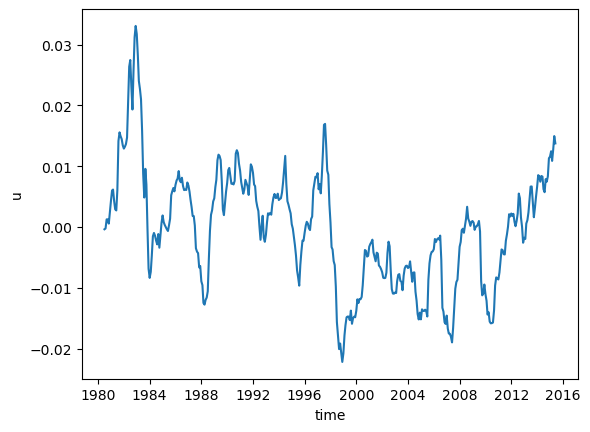

In [57]:
u = xr.open_dataset('UV_velocities.nc').compute().transpose('time','lat','lon')
u = u.where(u!=0,np.nan)
mask_edge = coastal_band_mask(u,'u',5).sel(lon=slice(-85,None),lat=slice(-16,-5))
u = u.where(mask_edge).u
Us =prep_for_taylor(u.mean(dim=('lat','lon')), dim='time', window=13, drop_en=False)
Us.plot()

In [58]:
# UGEO
UGEOs = prep_for_taylor((UGEO).mean(dim=('lat_band','lon')), dim='time', window=13, drop_en=False)
UGEOs

<xarray.DataArray 'UGEO' (time: 420)> Size: 3kB
array([ 0.06674499,  0.06816352,  0.06783984,  0.05657595,  0.06249554,
        0.02948083, -0.04058571, -0.08067413, -0.11017534, -0.07355127,
       -0.04194365, -0.03576839, -0.06768077, -0.13778109, -0.19340258,
       -0.21938115, -0.20903889, -0.21490842, -0.19806276, -0.1877185 ,
       -0.1797158 , -0.17196811, -0.2461787 , -0.31841786, -0.37540149,
       -0.38213605, -0.34088735, -0.36029487, -0.50820777, -0.6994128 ,
       -0.76014531, -0.73620819, -0.71180112, -0.68320811, -0.65258627,
       -0.56948327, -0.48791531, -0.42041338, -0.40081308, -0.36707034,
       -0.28344481, -0.09622447,  0.11536219,  0.17721036,  0.15766673,
        0.16411081,  0.15779546,  0.14911049,  0.14206619,  0.14023226,
        0.14768385,  0.17263091,  0.177982  ,  0.1851893 ,  0.18577368,
        0.16539407,  0.18152197,  0.21387717,  0.22891382,  0.23068129,
        0.23147088,  0.2329935 ,  0.21202929,  0.19247674,  0.18390749,
        0.16334892,  0.12917608,  0.11263478,  0.10763508,  0.08463647,
        0.06717035,  0.07517391,  0.05290177,  0.03772261,  0.02107141,
        0.01215547, -0.01295707, -0.02977488, -0.00818884,  0.01075869,
        0.0258013 ,  0.05734301,  0.08396917,  0.08795027,  0.07844279,
        0.09571363,  0.11077766,  0.13535185,  0.18141746,  0.22079516,
        0.25123774,  0.25634664,  0.26475812,  0.2609062 ,  0.25634833,
        0.26194991,  0.26211312,  0.26377714,  0.25144492,  0.23920868,
...
        0.00302236,  0.01093751,  0.01995315,  0.04344981,  0.07631999,
        0.08642597,  0.0888869 ,  0.09512421,  0.09856023,  0.07934755,
        0.07152533,  0.04919547,  0.06360143,  0.05709119,  0.07445675,
        0.08786267,  0.09188825,  0.08454835,  0.08438739,  0.10545379,
        0.12023213,  0.11853737,  0.1111692 ,  0.0942353 ,  0.06271657,
        0.0549442 ,  0.08067566,  0.05370421,  0.00352754, -0.01462083,
       -0.01984508, -0.02394411, -0.05951445, -0.10916367, -0.16451798,
       -0.14124501, -0.11021871, -0.09395662, -0.06690717, -0.05922906,
       -0.03650189,  0.00178102,  0.00962675,  0.01671975,  0.00561328,
        0.0202904 ,  0.02653918,  0.02086516,  0.01810427, -0.00133959,
        0.02875106,  0.03716977,  0.03575932,  0.03984111,  0.03364547,
        0.04248081,  0.03453038,  0.07807957,  0.07925338,  0.08382826,
        0.14837249,  0.16361842,  0.17590104,  0.16561314,  0.15352736,
        0.14466272,  0.12700881,  0.1330408 ,  0.14153244,  0.15601862,
        0.13134608,  0.14382721,  0.17407923,  0.16158631,  0.14874003,
        0.14853047,  0.14263559,  0.12746293,  0.12544638,  0.13723503,
        0.13466708,  0.10068715,  0.05329452,  0.04136781,  0.02017736,
        0.01615208, -0.00416984, -0.02416927, -0.0338678 , -0.03577285,
       -0.03025324, -0.03422507, -0.0426115 , -0.05493558, -0.09290341,
       -0.1012652 , -0.09352917, -0.13325115, -0.23843535, -0.27469355])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-07-31 1980-08-31 ... 2015-06-30
    month    (time) int64 3kB 7 8 9 10 11 12 1 2 3 4 ... 9 10 11 12 1 2 3 4 5 6

In [59]:
t_alongs = prep_for_taylor(t_along.mean(dim=('lat')), dim='time', window=13, drop_en=False)
t_alongs

<xarray.DataArray 'tau_alongshore' (time: 420)> Size: 3kB
array([-2.64570719e-03, -3.40764115e-03, -3.81892997e-03, -4.08110065e-03,
       -4.44423610e-03, -4.49794550e-03, -4.11129999e-03, -4.65587630e-03,
       -4.43632129e-03, -4.53710418e-03, -4.57310127e-03, -4.38204590e-03,
       -3.98830182e-03, -3.36370424e-03, -2.24431125e-03, -2.15405901e-03,
       -2.28535601e-03, -1.45784547e-03, -2.00844815e-03, -2.25561780e-03,
       -2.18592507e-03, -2.22425987e-03, -2.01852545e-03, -1.47695597e-03,
       -3.97468984e-04,  7.09527306e-04,  4.50285463e-04, -1.23008508e-04,
        9.07060936e-04,  2.56885882e-03,  3.48511691e-03,  4.64498075e-03,
        6.56621722e-03,  6.95196869e-03,  6.57091904e-03,  5.68779246e-03,
        4.40381338e-03,  3.22490936e-03,  1.86881145e-03,  1.26925166e-03,
        1.08657052e-03, -3.85491012e-04, -2.84490812e-03, -3.79975342e-03,
       -4.69368688e-03, -6.77163349e-03, -7.25914776e-03, -6.83014720e-03,
       -6.25289293e-03, -5.95389388e-03, -6.85841761e-03, -7.08815304e-03,
       -7.74198191e-03, -8.89966431e-03, -8.78845444e-03, -7.70146536e-03,
       -7.93873689e-03, -8.46356266e-03, -8.41411525e-03, -8.29649836e-03,
       -8.54130951e-03, -9.00116785e-03, -8.47179132e-03, -7.34994212e-03,
       -7.42229904e-03, -6.75002471e-03, -6.49747227e-03, -6.64887923e-03,
       -6.42294036e-03, -6.48897854e-03, -5.39090504e-03, -5.61651812e-03,
       -4.68207493e-03, -3.54436002e-03, -2.01582282e-03, -1.73283587e-03,
       -1.06274320e-03, -7.33831696e-04, -1.17185947e-03, -6.55875636e-04,
...
       -1.13970277e-03, -1.49515582e-03, -1.12390049e-03, -1.08778283e-03,
        9.54792133e-04,  3.36736834e-04, -3.93564251e-04,  1.06378427e-03,
        3.23968645e-03,  4.37029329e-03,  5.96464135e-03,  6.97703676e-03,
        8.36930384e-03,  9.40759149e-03,  1.09826066e-02,  9.87004875e-03,
        9.96608396e-03,  8.75941556e-03,  8.74432910e-03,  8.69284116e-03,
        7.27517008e-03,  5.12138371e-03,  4.40324821e-03,  3.14463645e-03,
        3.34957335e-03,  3.38938916e-03,  3.83105224e-03,  3.78490064e-03,
        3.34451111e-03,  3.21318205e-03,  2.12850577e-03,  1.97709599e-03,
        1.65546333e-03,  1.14175704e-03,  1.36827834e-03,  5.75780433e-04,
        2.37201839e-04, -8.82700849e-04, -1.02773355e-03, -1.19949642e-03,
       -2.83506587e-03, -2.72949139e-03, -2.53757875e-03, -2.31861311e-03,
       -2.11060532e-03, -2.54220961e-03, -1.72006861e-03, -1.07600512e-03,
       -8.83687352e-04, -5.88027091e-04, -6.21011261e-04, -1.41911891e-03,
       -3.54941376e-03, -3.54301662e-03, -3.97126647e-03, -5.19562202e-03,
       -5.85148819e-03, -5.59339094e-03, -4.90408718e-03, -4.39059913e-03,
       -4.18974850e-03, -3.13961104e-03, -2.59831778e-03, -3.31493824e-03,
       -2.76486600e-03, -2.53805934e-03, -2.06025298e-03, -8.26779473e-04,
        4.39603158e-04,  7.73771621e-04, -5.16620196e-04, -6.36709547e-04,
       -4.41416668e-04, -1.22949232e-03, -1.13917279e-03, -1.68410214e-03,
       -1.18107214e-03, -8.37519071e-04,  1.16829007e-03,  2.18745099e-03])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-07-31 1980-08-31 ... 2015-06-30
    month    (time) int64 3kB 7 8 9 10 11 12 1 2 3 4 ... 9 10 11 12 1 2 3 4 5 6

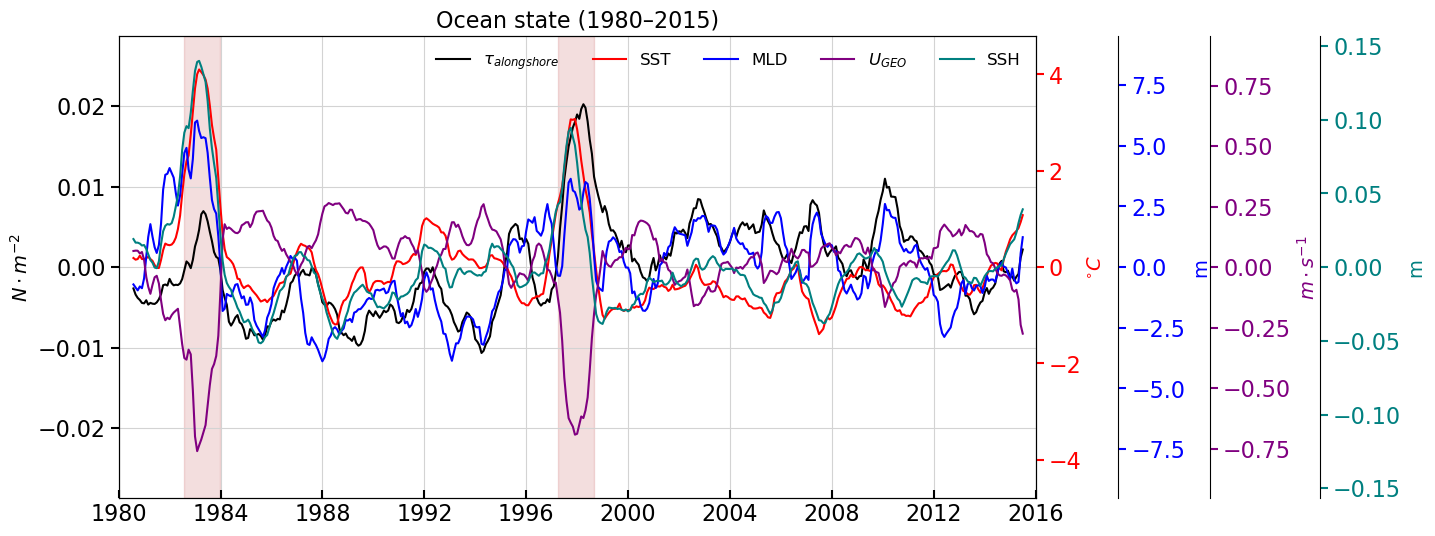

In [61]:
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle

lp=4

def make_patch_spines_invisible(ax):
    ax.set_frame_on(True)
    ax.patch.set_visible(False)
    for sp in ax.spines.values():
        sp.set_visible(False)

fig, host = plt.subplots(figsize=(14, 6))

# Extra y-axes
par1 = host.twinx()
par2 = host.twinx()
par3 = host.twinx()
par4 = host.twinx()

# Offset the extra spines
par2.spines["right"].set_position(("axes", 1.07+0.02))
par3.spines["right"].set_position(("axes", 1.16+0.03))
par4.spines["right"].set_position(("axes", 1.26+0.05))

make_patch_spines_invisible(par2)
make_patch_spines_invisible(par3)
make_patch_spines_invisible(par4)
par2.spines["right"].set_visible(True)
par3.spines["right"].set_visible(True)
par4.spines["right"].set_visible(True)

# --- Plot each variable on its own axis ---
p1, = host.plot(t_alongs.time, t_alongs, lw=1.5, color='black',   label=r'$\tau_{alongshore}$')
p2, = par1.plot(SSTs.time,     SSTs,     lw=1.5, color='red',     label='SST')
p3, = par2.plot(MLDs.time,     MLDs,     lw=1.5, color='blue',    label='MLD')
p4, = par3.plot(UGEOs.time,    UGEOs,    lw=1.5, color='purple', label=r'$U_{GEO}$')
p5, = par4.plot(SSHs.time,     SSHs,     lw=1.5, color='teal', label='SSH')

# ---- Y-lim labels
k = 5  # adjust if needed (2–3 is typical)

host.set_ylim(-k * t_alongs.std().item(), k * t_alongs.std().item())
par1.set_ylim(-k * SSTs.std().item(),     k * SSTs.std().item())
par2.set_ylim(-k * MLDs.std().item(),     k * MLDs.std().item())
par3.set_ylim(-k * UGEOs.std().item(),    k * UGEOs.std().item())
par4.set_ylim(-k * SSHs.std().item(),     k * SSHs.std().item())

# --- Y-axis labels with matching colors ---
host.set_ylabel(r'$N \cdot m^{-2}$', fontsize=14, labelpad=lp)
par1.set_ylabel('$^{\circ}C$', fontsize=14, labelpad=lp)
par2.set_ylabel('m', fontsize=14, labelpad=lp)
par3.set_ylabel(r'$m \cdot s^{-1}$', fontsize=14, labelpad=lp)
par4.set_ylabel('m', fontsize=14, labelpad=lp)

host.yaxis.label.set_color('black')
par1.yaxis.label.set_color('red')
par2.yaxis.label.set_color('blue')
par4.yaxis.label.set_color('teal')
par3.yaxis.label.set_color('purple')

# --- Tick colors ---
tkw = dict(size=6, width=1.5)
host.tick_params(axis='y', colors='black',  labelsize=12, **tkw)
par1.tick_params(axis='y', colors='red',    labelsize=12, **tkw)
par2.tick_params(axis='y', colors='blue',   labelsize=12, **tkw)
par4.tick_params(axis='y', colors='teal',  labelsize=12, **tkw)
par3.tick_params(axis='y', colors='purple', labelsize=12, **tkw)
host.tick_params(axis='x', direction='in', labelsize=12, **tkw)

# --- EN rectangles ---
# NINO = [
#     (datetime.datetime(1982, 8, 1), datetime.datetime(1983, 12, 31)),
#     (datetime.datetime(1997, 4, 1), datetime.datetime(1998, 8, 30)),
# ]
rectangles = [
    (datetime.datetime(1982, 8, 1),  datetime.datetime(1983, 12, 31)),
    (datetime.datetime(1997, 4, 1),  datetime.datetime(1998, 8, 30)),
]
for start, end in rectangles:
    rect = Rectangle(
        (mdates.date2num(start), host.get_ylim()[0]),
        mdates.date2num(end) - mdates.date2num(start),
        host.get_ylim()[1] - host.get_ylim()[0],
        facecolor='firebrick', edgecolor='firebrick',
        alpha=0.15, zorder=0,
    )
    host.add_patch(rect)

# --- X-axis formatting ---
host.set_xlim(datetime.datetime(1980, 1, 1), datetime.datetime(2016, 1, 1))
# host.xaxis.set_major_locator(mdates.YearLocator(base=2))
# host.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# --- Legend ---
handles = [p1, p2, p3, p4, p5]
labels  = [h.get_label() for h in handles]
fig.subplots_adjust(right=0.78)
host.legend(handles, labels, fontsize=12, loc='upper right',
            bbox_to_anchor=(1.0, 1.0), frameon=False, ncol=5)

host.grid(True, color='lightgrey')
host.set_axisbelow(True)
host.tick_params(axis='both', which='major', labelsize=16)
par1.tick_params(axis='both', which='major', labelsize=16)
par2.tick_params(axis='both', which='major', labelsize=16)
par3.tick_params(axis='both', which='major', labelsize=16)
par4.tick_params(axis='both', which='major', labelsize=16)
    
plt.title('Ocean state (1980–2015)', fontsize=16)

# with PdfPages('figures/Ocean_state_anomalies_2.pdf') as pdf:
#     pdf.savefig(fig, bbox_inches='tight')

plt.show()

In [62]:
def prep_for_taylor(da, dim='time',window=12, drop_en=False):
    """Climatology removal → running mean → drop NaNs → optionally drop EN."""
    clim = da.groupby(f'{dim}.month').mean(dim=dim)
    anom = da.groupby(f'{dim}.month') - clim
    smooth = anom.rolling({dim: window}, center=True).mean().dropna(dim=dim)
    
    if drop_en:
        smooth = drop_en_events(smooth)
    return smooth


In [79]:
# Prepare all series
wmld_ts   = prep_for_taylor(wmld.WMLD.mean(dim=('lat','lon')))
CROCO_j_ts = prep_for_taylor(CROCO_j.mean(dim=('lon','lat_band')))

AV_ts   = prep_for_taylor(AV.mean(dim=('lat','lon')))
Ekt_ts  = prep_for_taylor(Ek_t.mean('lat'))
CUTI_ts = prep_for_taylor((CUTI/d).mean(dim=('lon','lat_band')))

BEUTI_ts = prep_for_taylor(BEUTI.mean(dim=('lon','lat_band')))
CUI_ts   = prep_for_taylor(CUI.CUI_cc.mean('lat'))
CHL_ts   = prep_for_taylor(CHL.chla.mean(dim=('lat','lon')))

(3652.0, 16801.0)

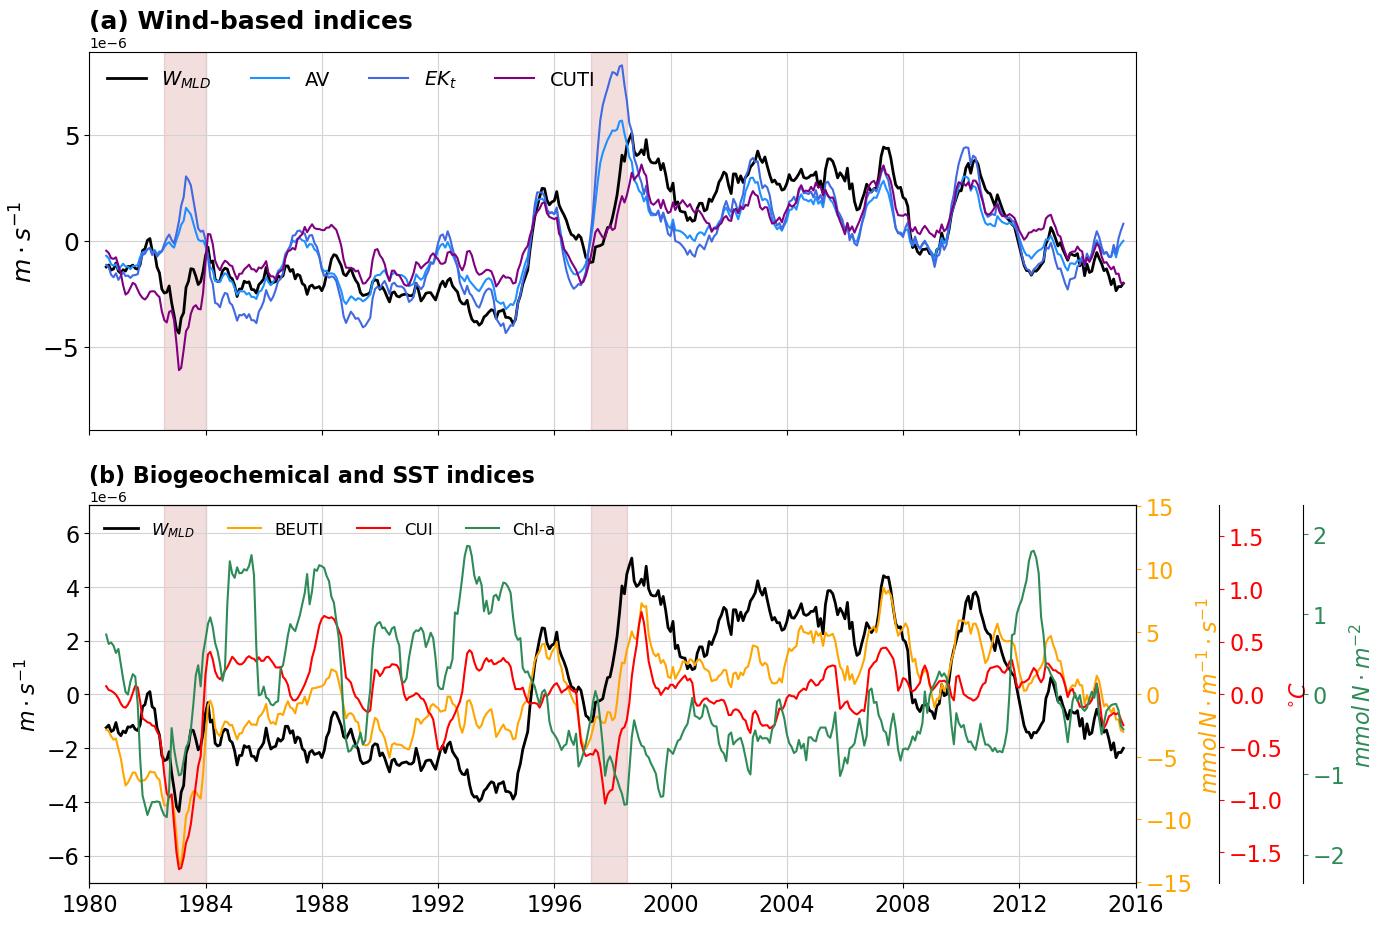

In [83]:
lw=2
def make_patch_spines_invisible(ax):
    ax.set_frame_on(True)
    ax.patch.set_visible(False)
    for sp in ax.spines.values():
        sp.set_visible(False)

rectangles = [
    (datetime.datetime(1982, 8, 1),  datetime.datetime(1983, 12, 31)),
    (datetime.datetime(1997, 4, 1),  datetime.datetime(1998, 6, 30)),
]

k = 3.8

fig, (ax_top, ax_bot_host) = plt.subplots(2, 1, figsize=(15*0.9, 12*0.9), sharex=True)

# ============================================================
# TOP PANEL — Wind-based indices (all m/s on one y-axis)
# ============================================================
ax_top.plot(wmld_ts.time,    wmld_ts,    lw=2,   color='black',      label=r'$W_{MLD}$')
ax_top.plot(AV_ts.time,      AV_ts,      lw=1.5, color='dodgerblue', label='AV')
ax_top.plot(Ekt_ts.time,     Ekt_ts,     lw=1.5, color='royalblue',  label=r'$EK_t$')
ax_top.plot(CUTI_ts.time,    CUTI_ts,    lw=1.5, color='purple',     label='CUTI')

ax_top.set_ylabel(r'$m \cdot s^{-1}$', fontsize=16+lw)
ax_top.set_ylim(-k * wmld_ts.std().item(), k * wmld_ts.std().item())
ax_top.legend(fontsize=12+lw, ncol=5, frameon=False, loc='upper left')
ax_top.grid(True, color='lightgrey')
ax_top.set_axisbelow(True)
ax_top.tick_params(axis='both', which='major', labelsize=16+lw)
ax_top.set_title('(a) Wind-based indices', fontsize=16+lw, loc='left', fontweight='bold')
# host.tick_params(axis='y', colors='black',  labelsize=12, **tkw)

# EN rectangles on top panel
for start, end in rectangles:
    rect = Rectangle(
        (mdates.date2num(start), ax_top.get_ylim()[0]),
        mdates.date2num(end) - mdates.date2num(start),
        ax_top.get_ylim()[1] - ax_top.get_ylim()[0],
        facecolor='firebrick', edgecolor='firebrick',
        alpha=0.15, zorder=0,
    )
    ax_top.add_patch(rect)

# ============================================================
# BOTTOM PANEL — WMLD (host) + BEUTI, CUI, Chl (extra axes)
# ============================================================
par1 = ax_bot_host.twinx()   # BEUTI
par2 = ax_bot_host.twinx()   # CUI
par3 = ax_bot_host.twinx()   # Chl

# Offset extra axes (clean spacing)
par2.spines["right"].set_position(("axes", 1.08))
par3.spines["right"].set_position(("axes", 1.16))

make_patch_spines_invisible(par2)
make_patch_spines_invisible(par3)
par2.spines["right"].set_visible(True)
par3.spines["right"].set_visible(True)

# --- Host: WMLD ---
p_w, = ax_bot_host.plot(
    wmld_ts.time, wmld_ts,
    lw=2, color='black', label=r'$W_{MLD}$'
)
ax_bot_host.set_ylabel(r'$m \cdot s^{-1}$', fontsize=16)
ax_bot_host.yaxis.label.set_color('black')
ax_bot_host.tick_params(axis='y', colors='black', labelsize=16)

# --- BEUTI ---
p_b, = par1.plot(
    BEUTI_ts.time, BEUTI_ts,
    lw=1.5, color='orange', label='BEUTI'
)
par1.set_ylabel(r'$mmol\,N \cdot m^{-1} \cdot s^{-1}$', fontsize=16)
par1.yaxis.label.set_color('orange')
par1.tick_params(axis='y', colors='orange', labelsize=16)

# --- CUI ---
p_c, = par2.plot(
    CUI_ts.time, CUI_ts,
    lw=1.5, color='red', label='CUI'
)
par2.set_ylabel(r'$^{\circ}C$', fontsize=16)
par2.yaxis.label.set_color('red')
par2.tick_params(axis='y', colors='red', labelsize=16)

# --- Chlorophyll ---
p_ch, = par3.plot(
    CHL_ts.time, CHL_ts,
    lw=1.5, color='seagreen', label='Chl-a'
)
par3.set_ylabel(r'$mmol\,N \cdot m^{-2}$', fontsize=16)
par3.yaxis.label.set_color('seagreen')
par3.tick_params(axis='y', colors='seagreen', labelsize=16)

# --- Symmetric limits (important for visual comparison) ---
k = 3
ax_bot_host.set_ylim(-k * wmld_ts.std().item(), k * wmld_ts.std().item())
par1.set_ylim(-4 * BEUTI_ts.std().item(), 4 * BEUTI_ts.std().item())
par2.set_ylim(-5 * CUI_ts.std().item(), 5 * CUI_ts.std().item())
par3.set_ylim(-k * CHL_ts.std().item(), k * CHL_ts.std().item())

# --- EN shading ---
for start, end in rectangles:
    rect = Rectangle(
        (mdates.date2num(start), ax_bot_host.get_ylim()[0]),
        mdates.date2num(end) - mdates.date2num(start),
        ax_bot_host.get_ylim()[1] - ax_bot_host.get_ylim()[0],
        facecolor='firebrick', edgecolor='firebrick',
        alpha=0.15, zorder=0,
    )
    ax_bot_host.add_patch(rect)

# --- Styling ---
ax_bot_host.grid(True, color='lightgrey')
ax_bot_host.set_axisbelow(True)
ax_bot_host.tick_params(axis='x', which='major', labelsize=16)

# --- Title ---
ax_bot_host.set_title(
    '(b) Biogeochemical and SST indices',
    fontsize=16, loc='left', fontweight='bold'
)

# --- Legend ---
handles = [p_w, p_b, p_c, p_ch]
labels  = [h.get_label() for h in handles]
ax_bot_host.legend(handles, labels, fontsize=12, ncol=4,
                   frameon=False, loc='upper left')

# --- X-axis ---
ax_bot_host.set_xlim(datetime.datetime(1980, 1, 1),
                     datetime.datetime(2016, 1, 1))

In [77]:
# Prepare all series
wmld_EN   = prep_for_taylor(wmld.WMLD.mean(dim=('lat','lon'))).sel(time=slice("1981-01-01","1984-12-31"))
CROCO_j_EN = prep_for_taylor(CROCO_j.mean(dim=('lon','lat_band'))).sel(time=slice("1981-01-01","1984-12-31"))

AV_EN   = prep_for_taylor(AV.mean(dim=('lat','lon'))).sel(time=slice("1981-01-01","1984-12-31"))
Ekt_EN  = prep_for_taylor(Ek_t.mean('lat')).sel(time=slice("1981-01-01","1984-12-31"))
CUTI_EN = prep_for_taylor((CUTI/d).mean(dim=('lon','lat_band'))).sel(time=slice("1981-01-01","1984-12-31"))

BEUTI_EN = prep_for_taylor(BEUTI.mean(dim=('lon','lat_band'))).sel(time=slice("1981-01-01","1984-12-31"))
CUI_EN   = prep_for_taylor(CUI.CUI_cc.mean('lat')).sel(time=slice("1981-01-01","1984-12-31"))
CHL_EN   = prep_for_taylor(CHL.chla.mean(dim=('lat','lon'))).sel(time=slice("1981-01-01","1984-12-31"))

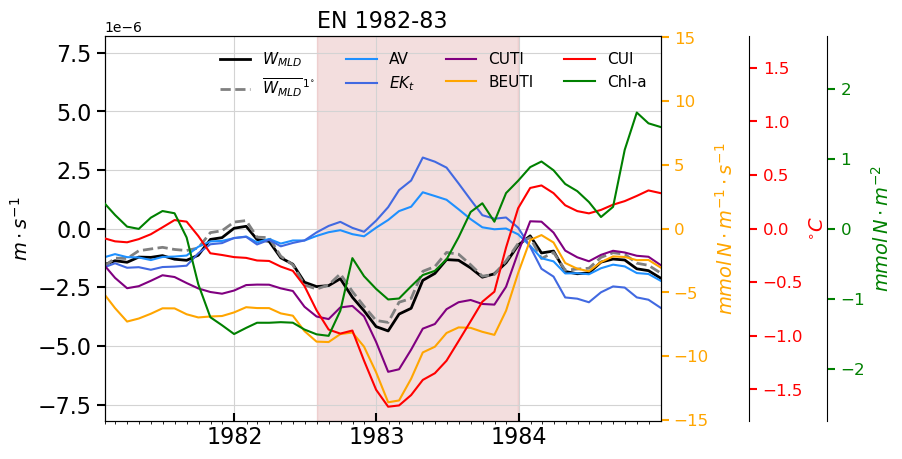

In [78]:
fig, host = plt.subplots(figsize=(8, 5))

par1 = host.twinx()          # BEUTI
par2 = host.twinx()          # CUI
par3 = host.twinx()          # Chl

par2.spines["right"].set_position(("axes", 1.14+0.02))
par3.spines["right"].set_position(("axes", 1.26+0.04))

make_patch_spines_invisible(par2)
make_patch_spines_invisible(par3)
par2.spines["right"].set_visible(True)
par3.spines["right"].set_visible(True)

# --- Host axis: all m/s indices ---
p1, = host.plot(wmld_EN.time,    wmld_EN,    lw=2,   color='black',      label=r'$W_{MLD}$')
p2, = host.plot(CROCO_j_EN.time, CROCO_j_EN, lw=2,   color='gray',       linestyle='--', label=r'$\overline{W_{MLD}}^{\,1^{\circ}}$')
p3, = host.plot(AV_EN.time,      AV_EN,      lw=1.5, color='dodgerblue', label='AV')
p4, = host.plot(Ekt_EN.time,     Ekt_EN,     lw=1.5, color='royalblue',  label=r'$EK_t$')
p5, = host.plot(CUTI_EN.time,    CUTI_EN,    lw=1.5, color='purple',     label='CUTI')

# --- Secondary axes ---
p6, = par1.plot(BEUTI_EN.time, BEUTI_EN, lw=1.5, color='orange', label='BEUTI')
p7, = par2.plot(CUI_EN.time,   CUI_EN,   lw=1.5, color='red',    label='CUI')
p8, = par3.plot(CHL_EN.time,   CHL_EN,   lw=1.5, color='green',  label='Chl-a')


# ------ Y limits -----
k = 3.5  # or 2.5 / 3 depending on how wide you want

host.set_ylim(-k * wmld_ts.std().item(), k * wmld_ts.std().item())
par1.set_ylim(-4 * BEUTI_ts.std().item(), 4 * BEUTI_ts.std().item())
par2.set_ylim(-5 * CUI_ts.std().item(), 5 * CUI_ts.std().item())
par3.set_ylim(-k * CHL_ts.std().item(), k * CHL_ts.std().item())

# --- Y-axis labels ---
host.set_ylabel(r'$m \cdot s^{-1}$',                          fontsize=14)
par1.set_ylabel(r'$mmol\,N \cdot m^{-1} \cdot s^{-1}$',       fontsize=14)
par2.set_ylabel(r'$^{\circ}C$',                                fontsize=14)
par3.set_ylabel(r'$mmol\,N \cdot m^{-2}$',                    fontsize=14)

host.yaxis.label.set_color('black')
par1.yaxis.label.set_color('orange')
par2.yaxis.label.set_color('red')
par3.yaxis.label.set_color('green')

# --- Tick colors ---
tkw = dict(size=6, width=1.5)
host.tick_params(axis='y', colors='black',  labelsize=12, **tkw)
par1.tick_params(axis='y', colors='orange', labelsize=12, **tkw)
par2.tick_params(axis='y', colors='red',    labelsize=12, **tkw)
par3.tick_params(axis='y', colors='green',  labelsize=12, **tkw)
host.tick_params(axis='x', direction='in',  labelsize=12, **tkw)

# --- EN rectangles ---
rectangles = [
    (datetime.datetime(1982, 8, 1),  datetime.datetime(1983, 12, 31)),
    (datetime.datetime(1997, 4, 1),  datetime.datetime(1998, 6, 30)),
]
for start, end in rectangles:
    rect = Rectangle(
        (mdates.date2num(start), host.get_ylim()[0]),
        mdates.date2num(end) - mdates.date2num(start),
        host.get_ylim()[1] - host.get_ylim()[0],
        facecolor='firebrick', edgecolor='firebrick',
        alpha=0.15, zorder=0,
    )
    host.add_patch(rect)

# --- X-axis --- 1984-12-31
host.set_xlim(datetime.datetime(1981, 2, 1), datetime.datetime(1984, 12, 31))
host.xaxis.set_major_locator(mdates.YearLocator(base=1))
host.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Minor ticks → every month
host.xaxis.set_minor_locator(mdates.MonthLocator())

# --- Legend ---
handles = [p1, p2, p3, p4, p5, p6, p7, p8]
labels  = [h.get_label() for h in handles]
fig.subplots_adjust(right=0.82)
host.legend(handles, labels, fontsize=11, loc='upper right',
            bbox_to_anchor=(1.0, 1.0), frameon=False, ncol=4)

host.grid(True, color='lightgrey')
host.set_axisbelow(True)
plt.title('EN 1982-83', fontsize=16)

host.tick_params(axis='both', which='major', labelsize=16)

# with PdfPages('figures/Upwelling_indices_EN8283.pdf') as pdf:
#     pdf.savefig(fig, bbox_inches='tight')

plt.show()

In [68]:
# Prepare all series
# start_date = datetime.datetime(1997, 4, 1)
# end_date = datetime.datetime(1998, 6, 30)

wmld_EN   = prep_for_taylor(wmld.WMLD.mean(dim=('lat','lon'))).sel(time=slice("1996-01-01","1999-12-31"))
CROCO_j_EN = prep_for_taylor(CROCO_j.mean(dim=('lon','lat_band'))).sel(time=slice("1996-01-01","1999-12-31"))

AV_EN   = prep_for_taylor(AV.mean(dim=('lat','lon'))).sel(time=slice("1996-01-01","1999-12-31"))
Ekt_EN  = prep_for_taylor(Ek_t.mean('lat')).sel(time=slice("1996-01-01","1999-12-31"))
CUTI_EN = prep_for_taylor((CUTI/d).mean(dim=('lon','lat_band'))).sel(time=slice("1996-01-01","1999-12-31"))

BEUTI_EN = prep_for_taylor(BEUTI.mean(dim=('lon','lat_band'))).sel(time=slice("1996-01-01","1999-12-31"))
CUI_EN   = prep_for_taylor(CUI.CUI_cc.mean('lat')).sel(time=slice("1996-01-01","1999-12-31"))
CHL_EN   = prep_for_taylor(CHL.chla.mean(dim=('lat','lon'))).sel(time=slice("1996-01-01","1999-12-31"))

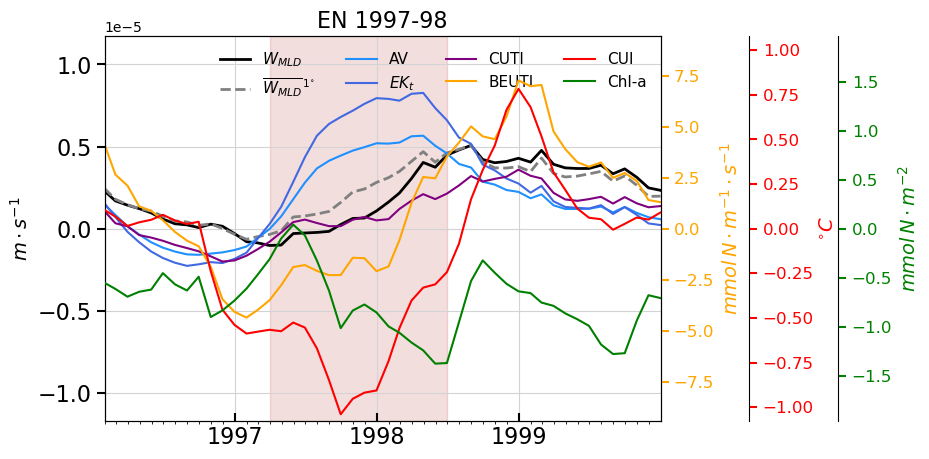

In [69]:
fig, host = plt.subplots(figsize=(8, 5))

par1 = host.twinx()          # BEUTI
par2 = host.twinx()          # CUI
par3 = host.twinx()          # Chl

par2.spines["right"].set_position(("axes", 1.14+0.02))
par3.spines["right"].set_position(("axes", 1.26+0.06))

make_patch_spines_invisible(par2)
make_patch_spines_invisible(par3)
par2.spines["right"].set_visible(True)
par3.spines["right"].set_visible(True)

# --- Host axis: all m/s indices ---
p1, = host.plot(wmld_EN.time,    wmld_EN,    lw=2,   color='black',      label=r'$W_{MLD}$')
p2, = host.plot(CROCO_j_EN.time, CROCO_j_EN, lw=2,   color='gray',       linestyle='--', label=r'$\overline{W_{MLD}}^{\,1^{\circ}}$')
p3, = host.plot(AV_EN.time,      AV_EN,      lw=1.5, color='dodgerblue', label='AV')
p4, = host.plot(Ekt_EN.time,     Ekt_EN,     lw=1.5, color='royalblue',  label=r'$EK_t$')
p5, = host.plot(CUTI_EN.time,    CUTI_EN,    lw=1.5, color='purple',     label='CUTI')

# --- Secondary axes ---
p6, = par1.plot(BEUTI_EN.time, BEUTI_EN, lw=1.5, color='orange', label='BEUTI')
p7, = par2.plot(CUI_EN.time,   CUI_EN,   lw=1.5, color='red',    label='CUI')
p8, = par3.plot(CHL_EN.time,   CHL_EN,   lw=1.5, color='green',  label='Chl-a')


# ------ Y limits -----
k = 2.5  # or 2.5 / 3 depending on how wide you want

host.set_ylim(-5 * wmld_ts.std().item(), 5 * wmld_ts.std().item())
par1.set_ylim(-k * BEUTI_ts.std().item(), k * BEUTI_ts.std().item())
par2.set_ylim(-3 * CUI_ts.std().item(), 3 * CUI_ts.std().item())
par3.set_ylim(-k * CHL_ts.std().item(), k * CHL_ts.std().item())

# --- Y-axis labels ---
host.set_ylabel(r'$m \cdot s^{-1}$',                          fontsize=14)
par1.set_ylabel(r'$mmol\,N \cdot m^{-1} \cdot s^{-1}$',       fontsize=14)
par2.set_ylabel(r'$^{\circ}C$',                                fontsize=14)
par3.set_ylabel(r'$mmol\,N \cdot m^{-2}$',                    fontsize=14)

host.yaxis.label.set_color('black')
par1.yaxis.label.set_color('orange')
par2.yaxis.label.set_color('red')
par3.yaxis.label.set_color('green')

# --- Tick colors ---
tkw = dict(size=6, width=1.5)
host.tick_params(axis='y', colors='black',  labelsize=12, **tkw)
par1.tick_params(axis='y', colors='orange', labelsize=12, **tkw)
par2.tick_params(axis='y', colors='red',    labelsize=12, **tkw)
par3.tick_params(axis='y', colors='green',  labelsize=12, **tkw)
host.tick_params(axis='x', direction='in',  labelsize=12, **tkw)

# --- EN rectangles ---
rectangles = [
    (datetime.datetime(1982, 8, 1),  datetime.datetime(1983, 12, 31)),
    (datetime.datetime(1997, 4, 1),  datetime.datetime(1998, 6, 30)),
]
for start, end in rectangles:
    rect = Rectangle(
        (mdates.date2num(start), host.get_ylim()[0]),
        mdates.date2num(end) - mdates.date2num(start),
        host.get_ylim()[1] - host.get_ylim()[0],
        facecolor='firebrick', edgecolor='firebrick',
        alpha=0.15, zorder=0,
    )
    host.add_patch(rect)

# --- X-axis --- "1996-01-01","1999-12-31"
host.set_xlim(datetime.datetime(1996, 2, 1), datetime.datetime(1999, 12, 31))
host.xaxis.set_major_locator(mdates.YearLocator(base=1))
host.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Minor ticks → every month
host.xaxis.set_minor_locator(mdates.MonthLocator())

# --- Legend ---
handles = [p1, p2, p3, p4, p5, p6, p7, p8]
labels  = [h.get_label() for h in handles]
fig.subplots_adjust(right=0.82)
host.legend(handles, labels, fontsize=11, loc='upper right',
            bbox_to_anchor=(1.0, 1.0), frameon=False, ncol=4)

host.grid(True, color='lightgrey')
host.set_axisbelow(True)
plt.title('EN 1997-98', fontsize=16)

host.tick_params(axis='both', which='major', labelsize=16)

# with PdfPages('figures/Upwelling_indices_EN9798.pdf') as pdf:
#     pdf.savefig(fig, bbox_inches='tight')


plt.show()